<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [1]:
# It is not guarantee it works, check previous version
#v1.5 We try to use a complex oscillation to fit the background at the same time as the complex lorentzian (ComplexLorentzianRipple_freq)

In [3]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_FMR, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func
import calculators as calcs

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [5]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\F264N4_p3\inP_010GaAs\FMR_2026-06-10")

In [6]:
file_name_1 = "2026-06-10_FMR_fsw_0Ato20Ain81_0p5to50GHz_-3dBm_19-41_analysis_test.h5.ma8"

In [7]:
sample = "F264N4_p3_inP_010GaAs"

In [8]:
geometry = "inP" #either "inP" or "outP"

In [9]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [10]:
ansy1 = Analysis_FMR(address1, file_name_1, sample, "FZU_FMR", geometry, vna_ref_subtracted)

In [11]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [20]:
if store_in_origin:
    newFile = ansy1.file
else:
    newfile_name =  s.replace(".h5.ma8", "_LorentzFits.h5")
    newFile = address1/newfile_name

fits_storage = FitStore (newFile, group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [23]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [24]:
#Ref. subtraction

In [25]:
ansy1.subtract_ref(single=False, fit=True, nb_g=1, ref_indx= 0) 
# ############It is saving a fuuuuull matrix of reference, no good

In [ ]:
#Recheck data after new ref

In [ ]:
# ansy1.plot_dij_slider('d_S', n_0=5)

In [ ]:
# Example of a single fit

{'Ar': -3.8116954723024134e-05, 'Ai': 6.926943078376839e-05, 'fo': 40.0, 'df': 0.02, 're0': 0.0, 'im0': 0.0, 'B': 0.0001, 'tau': 0.32684723811756117, 'phi': 0.0017006321037790683}
Initial simplex fit


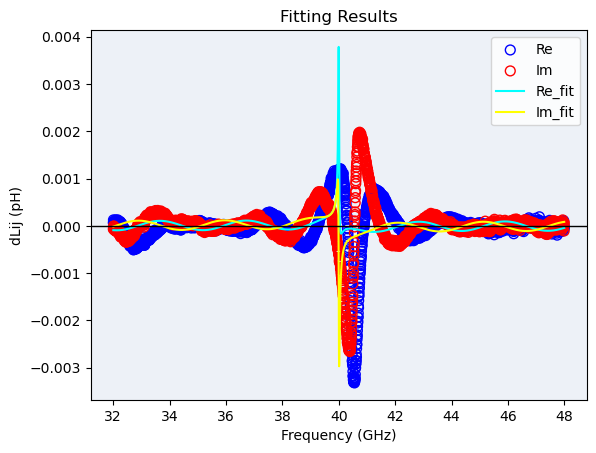

Final fit and results


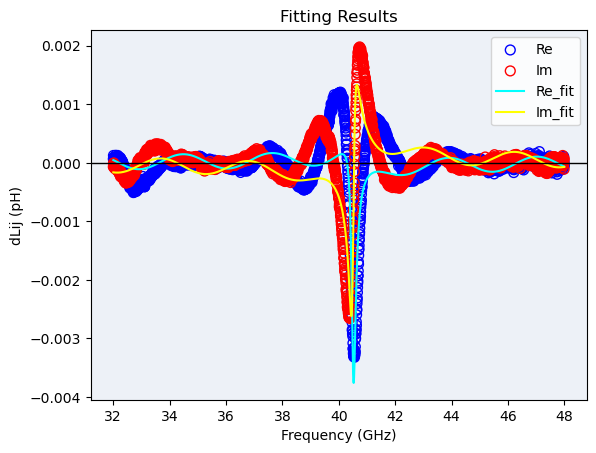


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.297e-04      5.464e-06                  No
Ai                    -3.505e-04      5.460e-06                  No
fo                       40.5084         0.0019                  No
df                        0.0934         0.0019                  No
re0                    0.000e+00              -        pH       Yes
im0                    0.000e+00              -        pH       Yes
B                      1.261e-04      5.565e-06                  No
tau                       0.3190         0.0015                  No
phi                       6.2832         0.3705       rad        No
----------------------------------------------------------------------
The phase is: 249.69731772450552


In [29]:
ini_vals = [1, 1, 35, 0.028, 0, 0, 0.0001, 0.175, 0] #"Ar","Ai","fo","df","re0","im0"
H_index = 28
f_center = 40

f_min, f_max = f_center-8, f_center+8 #GHz
f_array = ansy1.freqs

y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
#y_array_re, y_array_im = dS21_Re_dH[H_index], dS21_Im_dH[H_index]

model = models.ComplexLorentzianRipple_freq()
fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
    f_array, y_array_re , y_array_im, model)
fitter.fix(fo=f_center, df=0.02, re0=0, im0=0, B=0.0001) #tau=0.4, phi=1) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

fitter.fix( re0=0, im0=0)
params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [21]:
#If we are happy with the fit, we can save it.

In [22]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [23]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Index= 0, Guide freq.=52.13066015550589


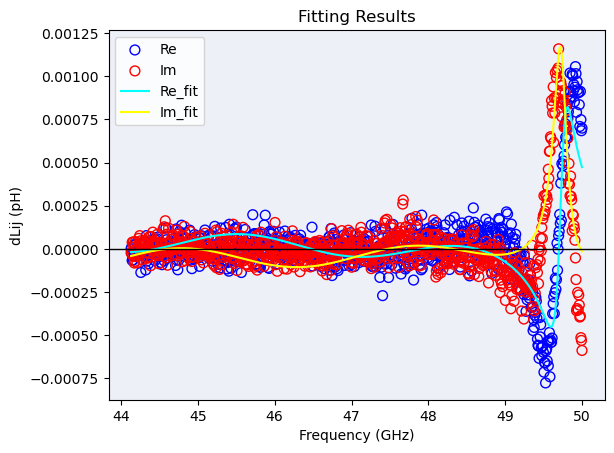


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.331e-04      3.627e-06                  No
Ai                     3.459e-05      3.684e-06                  No
fo                       49.7296         0.0032                  No
df                        0.1065         0.0031                  No
re0                    6.029e-05      4.278e-06        pH        No
im0                   -6.036e-05      4.280e-06        pH        No
B                      5.684e-05      4.101e-06                  No
tau                       0.3294         0.0079                  No
phi                    7.059e-18         2.3032       rad        No
----------------------------------------------------------------------
Index= 1, Guide freq.=51.81453230125644


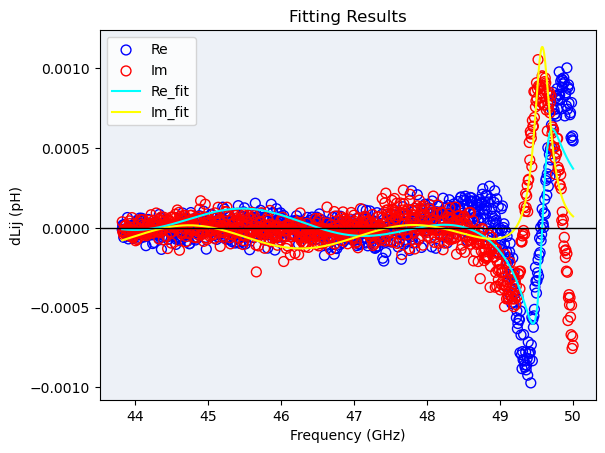


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.702e-04      4.911e-06                  No
Ai                    -1.297e-05      5.859e-06                  No
fo                       49.5718         0.0048                  No
df                        0.1359         0.0045                  No
re0                    9.028e-05      5.382e-06        pH        No
im0                   -5.479e-05      5.392e-06        pH        No
B                      7.263e-05      5.197e-06                  No
tau                       0.3260         0.0076                  No
phi                       1.0505         2.2150       rad        No
----------------------------------------------------------------------
Index= 2, Guide freq.=51.476181845995114


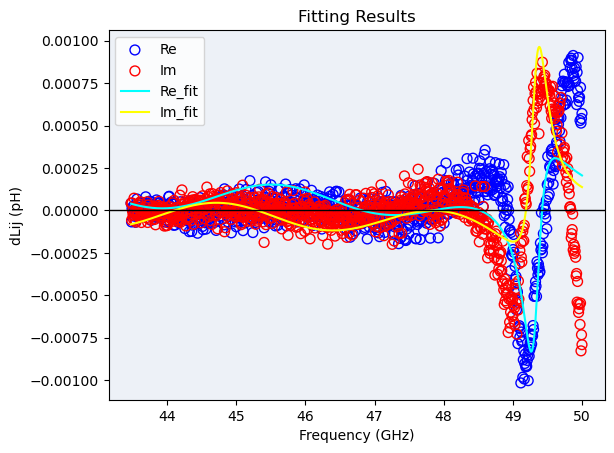


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.266e-04      6.186e-06                  No
Ai                    -1.129e-04      6.373e-06                  No
fo                       49.3286         0.0060                  No
df                        0.1425         0.0054                  No
re0                    1.113e-04      5.943e-06        pH        No
im0                   -6.797e-06      5.952e-06        pH        No
B                      7.539e-05      5.895e-06                  No
tau                       0.3074         0.0080                  No
phi                       6.2832         2.3204       rad        No
----------------------------------------------------------------------
Index= 3, Guide freq.=51.127421668844434


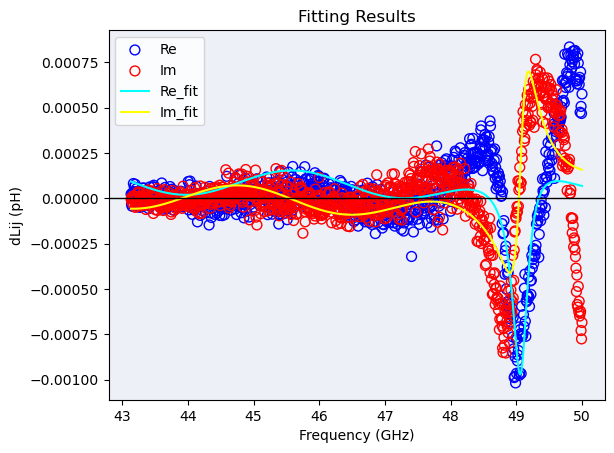


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.713e-05      7.317e-06                  No
Ai                    -1.593e-04      5.832e-06                  No
fo                       49.0745         0.0067                  No
df                        0.1427         0.0059                  No
re0                    9.697e-05      6.228e-06        pH        No
im0                    3.885e-05      6.131e-06        pH        No
B                      6.939e-05      6.236e-06                  No
tau                       0.3071         0.0086                  No
phi                       6.2832         2.4677       rad        No
----------------------------------------------------------------------
Index= 4, Guide freq.=50.78165154926629


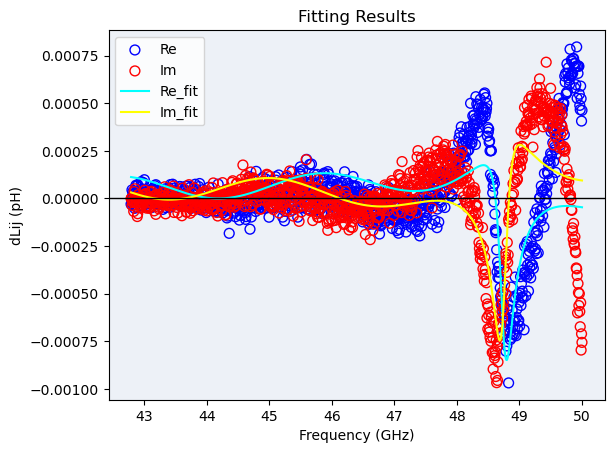


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.977e-05      6.417e-06                  No
Ai                    -1.097e-04      6.320e-06                  No
fo                       48.7475         0.0071                  No
df                        0.1336         0.0064                  No
re0                    4.223e-05      6.307e-06        pH        No
im0                    7.611e-05      6.152e-06        pH        No
B                      6.126e-05      6.389e-06                  No
tau                       0.3054         0.0089                  No
phi                       6.2832         2.5646       rad        No
----------------------------------------------------------------------
Index= 5, Guide freq.=50.43917463985468


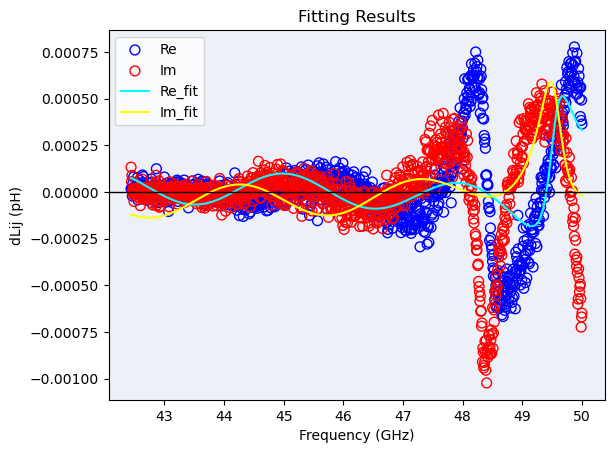


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.463e-04      1.231e-05                  No
Ai                     9.417e-05      9.943e-06                  No
fo                       49.5364         0.0164                  No
df                        0.2427         0.0160                  No
re0                    4.293e-05      7.896e-06        pH        No
im0                   -6.574e-05      7.358e-06        pH        No
B                      8.687e-05      6.467e-06                  No
tau                       0.3333         0.0069                  No
phi                   3.134e-193         1.9664       rad        No
----------------------------------------------------------------------
Index= 6, Guide freq.=50.037766722965394


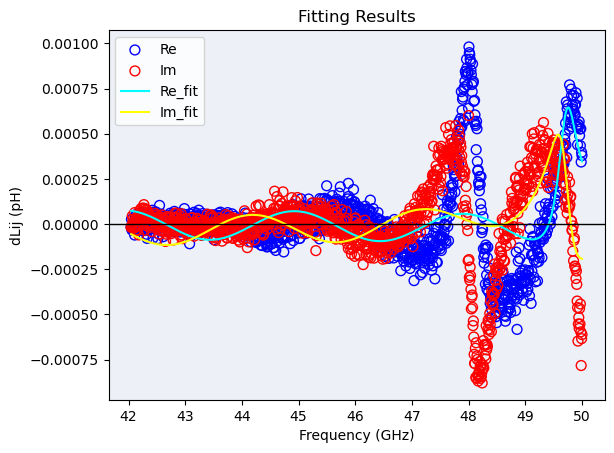


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.490e-05      1.171e-05                  No
Ai                     1.399e-04      9.946e-06                  No
fo                       49.7067         0.0160                  No
df                        0.2089         0.0155                  No
re0                    2.828e-06      7.691e-06        pH        No
im0                   -5.572e-05      7.464e-06        pH        No
B                      8.059e-05      6.479e-06                  No
tau                       0.3339         0.0066                  No
phi                    1.210e-54         1.8923       rad        No
----------------------------------------------------------------------
Index= 7, Guide freq.=49.652849310459025


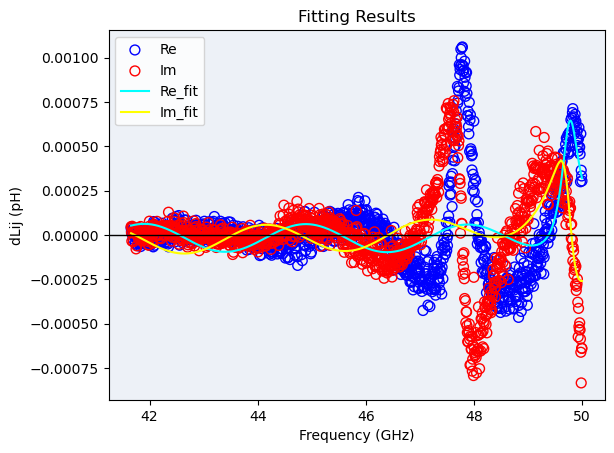


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.712e-05      1.115e-05                  No
Ai                     1.382e-04      1.019e-05                  No
fo                       49.7627         0.0165                  No
df                        0.1965         0.0160                  No
re0                   -1.321e-05      7.455e-06        pH        No
im0                   -4.607e-05      7.335e-06        pH        No
B                      7.855e-05      6.399e-06                  No
tau                       0.3341         0.0061                  No
phi                    2.477e-54         1.7416       rad        No
----------------------------------------------------------------------
Index= 8, Guide freq.=49.27032533112111


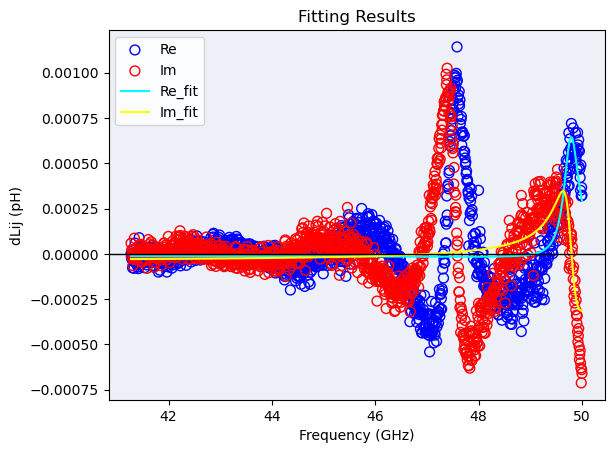


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.065e-05      9.079e-06                  No
Ai                     1.137e-04      9.081e-06                  No
fo                       49.7775         0.0166                  No
df                        0.1753         0.0164                  No
re0                   -1.062e-05      7.142e-06        pH        No
im0                   -4.257e-05      7.132e-06        pH        No
B                      1.661e-07      6.070e-06                  No
tau                       3.5530         2.3313                  No
phi                       0.2859       668.7555       rad        No
----------------------------------------------------------------------
Index= 9, Guide freq.=48.82128793332281


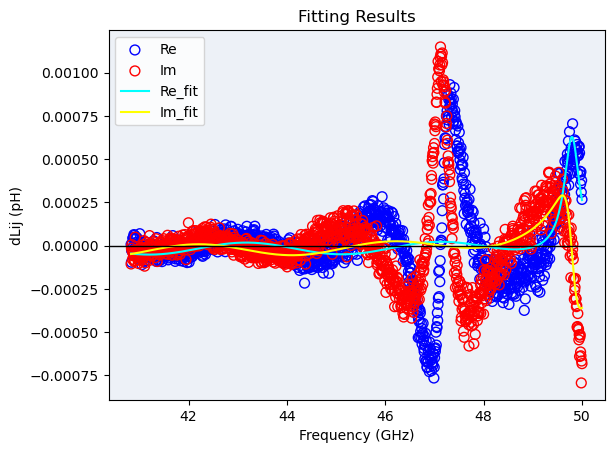


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -9.138e-06      1.090e-05                  No
Ai                     1.231e-04      1.228e-05                  No
fo                       49.8009         0.0185                  No
df                        0.1865         0.0192                  No
re0                   -1.887e-05      7.343e-06        pH        No
im0                   -4.276e-05      7.701e-06        pH        No
B                      3.448e-05      6.471e-06                  No
tau                       0.2548         0.0134                  No
phi                       6.2832         3.7813       rad        No
----------------------------------------------------------------------
Index= 10, Guide freq.=48.39091947819326


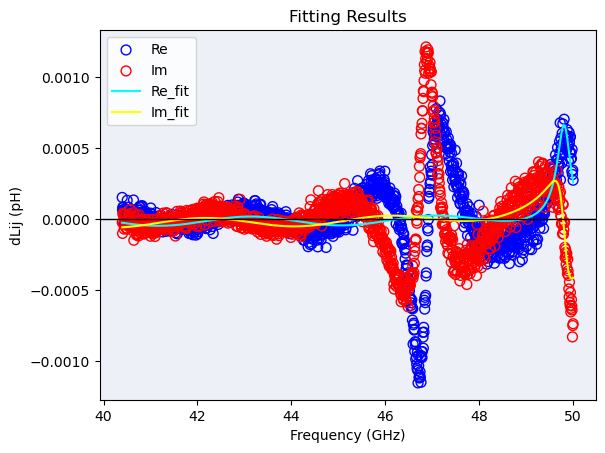


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.302e-05      1.124e-05                  No
Ai                     1.205e-04      1.287e-05                  No
fo                       49.8229         0.0187                  No
df                        0.1770         0.0193                  No
re0                   -1.628e-05      7.630e-06        pH        No
im0                   -3.804e-05      8.053e-06        pH        No
B                      3.221e-05      6.782e-06                  No
tau                       0.2562         0.0141                  No
phi                       5.9744         3.9693       rad        No
----------------------------------------------------------------------
Index= 11, Guide freq.=47.926521239954326


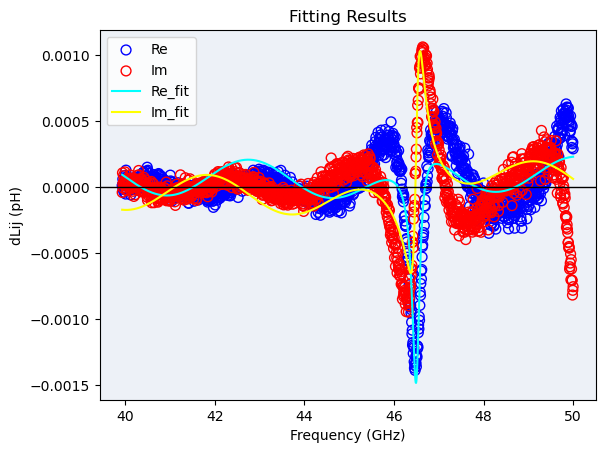


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.366e-05      4.088e-06                  No
Ai                    -1.731e-04      4.070e-06                  No
fo                       46.5030         0.0031                  No
df                        0.1033         0.0031                  No
re0                    8.326e-05      4.669e-06        pH        No
im0                   -7.843e-06      4.620e-06        pH        No
B                      1.377e-04      4.767e-06                  No
tau                       0.2728         0.0018                  No
phi                       2.1045         0.5077       rad        No
----------------------------------------------------------------------
Index= 12, Guide freq.=47.46567445587516


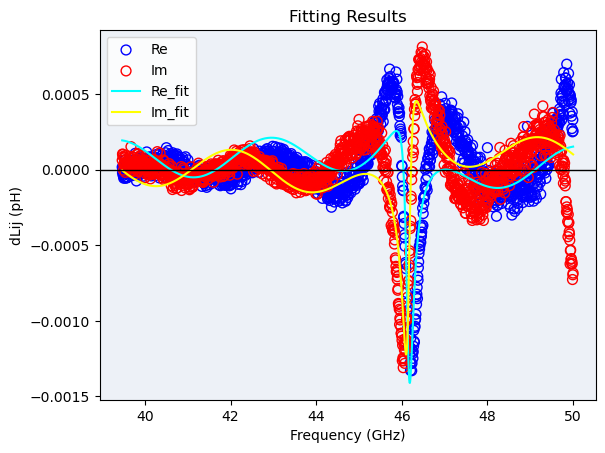


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.007e-04      4.049e-06                  No
Ai                    -1.467e-04      4.009e-06                  No
fo                       46.1540         0.0031                  No
df                        0.1033         0.0031                  No
re0                    5.451e-05      4.550e-06        pH        No
im0                    4.088e-05      4.486e-06        pH        No
B                      1.258e-04      4.614e-06                  No
tau                       0.2793         0.0018                  No
phi                       0.0465         0.5195       rad        No
----------------------------------------------------------------------
Index= 13, Guide freq.=46.99085012847677


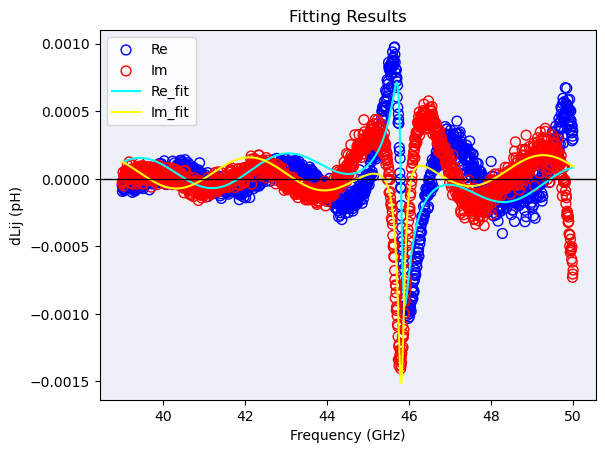


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.683e-04      3.942e-06                  No
Ai                    -2.947e-05      3.957e-06                  No
fo                       45.8120         0.0031                  No
df                        0.1010         0.0031                  No
re0                    1.166e-05      4.397e-06        pH        No
im0                    5.150e-05      4.386e-06        pH        No
B                      1.169e-04      4.495e-06                  No
tau                       0.2791         0.0019                  No
phi                    1.407e-30         0.5180       rad        No
----------------------------------------------------------------------
Index= 14, Guide freq.=46.482497741861096


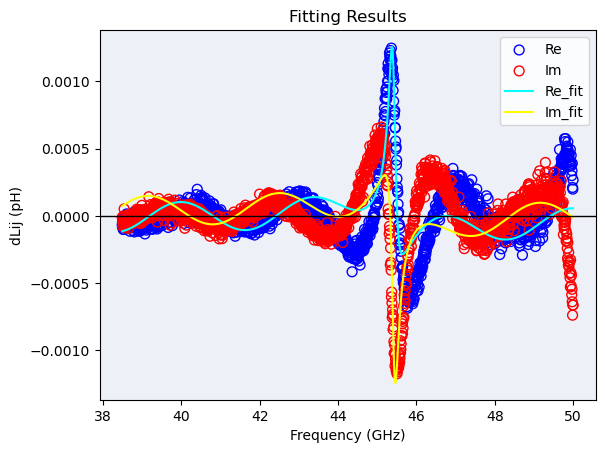


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.157e-04      3.863e-06                  No
Ai                     1.185e-04      3.871e-06                  No
fo                       45.4183         0.0032                  No
df                        0.1042         0.0032                  No
re0                   -2.783e-05      4.137e-06        pH        No
im0                    2.131e-05      4.138e-06        pH        No
B                      1.092e-04      4.254e-06                  No
tau                       0.3002         0.0018                  No
phi                       6.2832         0.4922       rad        No
----------------------------------------------------------------------
Index= 15, Guide freq.=46.00369169375738


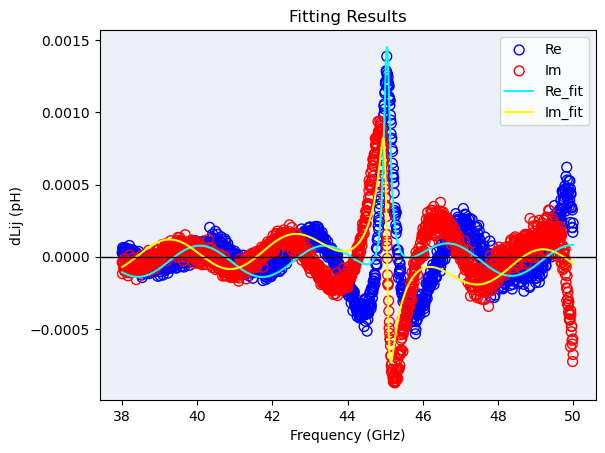


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.267e-05      3.731e-06                  No
Ai                     1.651e-04      3.693e-06                  No
fo                       45.0439         0.0031                  No
df                        0.1038         0.0031                  No
re0                   -2.982e-05      3.905e-06        pH        No
im0                   -1.723e-05      3.922e-06        pH        No
B                      1.084e-04      4.013e-06                  No
tau                       0.3023         0.0016                  No
phi                       5.5575         0.4485       rad        No
----------------------------------------------------------------------
Index= 16, Guide freq.=45.472821081215294


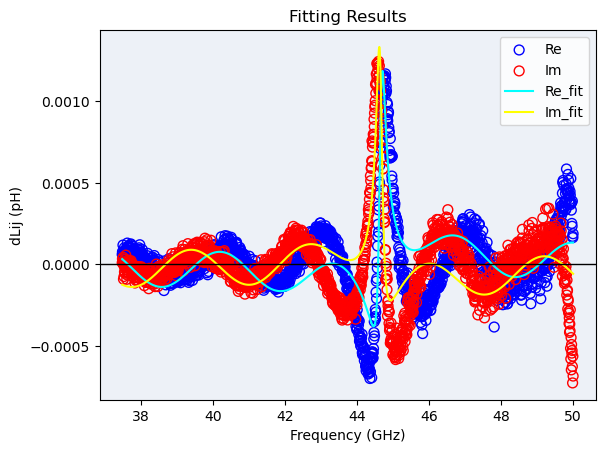


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.388e-04      3.651e-06                  No
Ai                     9.803e-05      3.646e-06                  No
fo                       44.6503         0.0030                  No
df                        0.1054         0.0030                  No
re0                   -3.762e-06      3.767e-06        pH        No
im0                   -4.093e-05      3.745e-06        pH        No
B                      1.117e-04      3.829e-06                  No
tau                       0.3059         0.0015                  No
phi                       4.4087         0.3988       rad        No
----------------------------------------------------------------------
Index= 17, Guide freq.=44.95478498877801


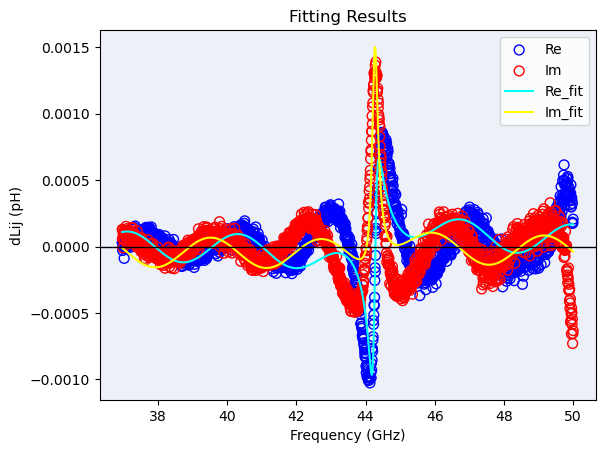


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.695e-04      3.613e-06                  No
Ai                    -3.925e-05      3.630e-06                  No
fo                       44.2598         0.0029                  No
df                        0.1040         0.0029                  No
re0                    2.445e-05      3.720e-06        pH        No
im0                   -3.791e-05      3.678e-06        pH        No
B                      1.127e-04      3.763e-06                  No
tau                       0.3111         0.0014                  No
phi                       2.8636         0.3720       rad        No
----------------------------------------------------------------------
Index= 18, Guide freq.=44.40854118924361


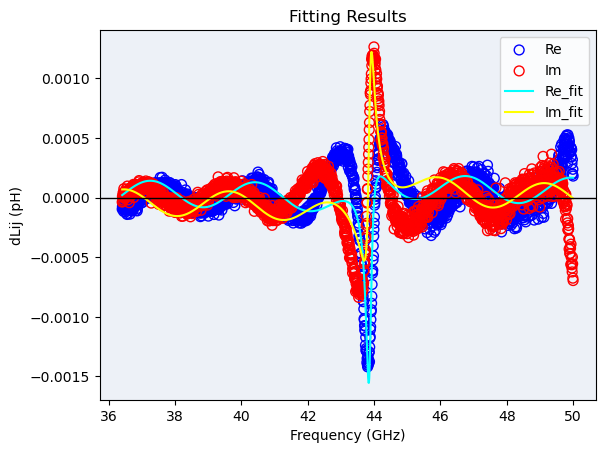


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.276e-05      3.681e-06                  No
Ai                    -1.617e-04      3.682e-06                  No
fo                       43.8630         0.0028                  No
df                        0.1011         0.0028                  No
re0                    4.567e-05      3.746e-06        pH        No
im0                   -1.782e-05      3.746e-06        pH        No
B                      1.092e-04      3.819e-06                  No
tau                       0.3156         0.0014                  No
phi                       1.5091         0.3695       rad        No
----------------------------------------------------------------------
Index= 19, Guide freq.=43.85783454705122


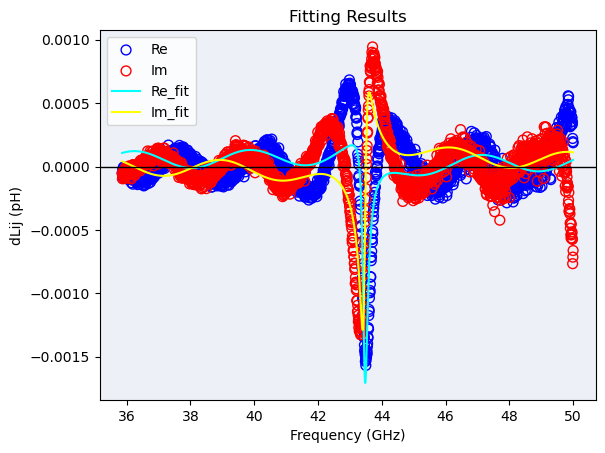


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.119e-05      4.001e-06                  No
Ai                    -1.673e-04      3.994e-06                  No
fo                       43.4643         0.0028                  No
df                        0.0958         0.0028                  No
re0                    4.380e-05      4.095e-06        pH        No
im0                    2.134e-05      4.114e-06        pH        No
B                      6.840e-05      4.179e-06                  No
tau                       0.2759         0.0023                  No
phi                    4.368e-42         0.6216       rad        No
----------------------------------------------------------------------
Index= 20, Guide freq.=43.34929229445871


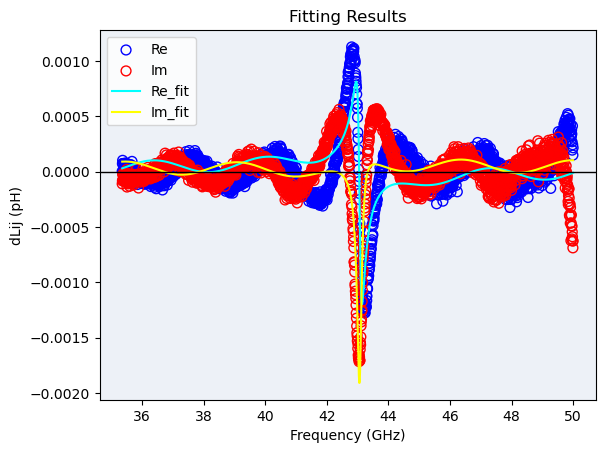


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.827e-04      4.007e-06                  No
Ai                    -4.415e-05      4.001e-06                  No
fo                       43.0704         0.0027                  No
df                        0.0926         0.0027                  No
re0                    1.611e-05      4.099e-06        pH        No
im0                    3.844e-05      4.141e-06        pH        No
B                      5.851e-05      4.191e-06                  No
tau                       0.2750         0.0026                  No
phi                    4.874e-53         0.7021       rad        No
----------------------------------------------------------------------
Index= 21, Guide freq.=42.81876332617643


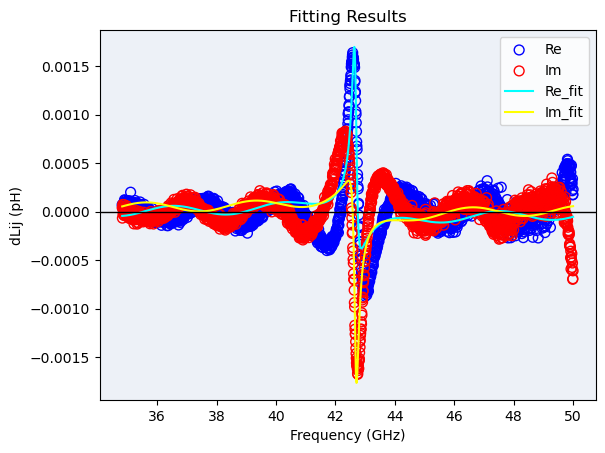


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.454e-04      4.031e-06                  No
Ai                     1.263e-04      4.032e-06                  No
fo                       42.6775         0.0026                  No
df                        0.0918         0.0026                  No
re0                   -1.485e-05      4.101e-06        pH        No
im0                    2.698e-05      4.095e-06        pH        No
B                      4.994e-05      4.173e-06                  No
tau                       0.2737         0.0029                  No
phi                    1.693e-45         0.7853       rad        No
----------------------------------------------------------------------
Index= 22, Guide freq.=42.24649027384221


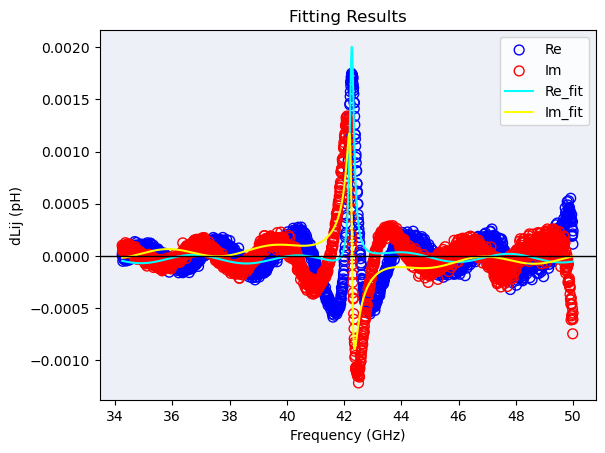


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.643e-05      3.981e-06                  No
Ai                     1.902e-04      3.981e-06                  No
fo                       42.2645         0.0026                  No
df                        0.0924         0.0026                  No
re0                   -2.594e-05      3.966e-06        pH        No
im0                   -4.815e-06      3.956e-06        pH        No
B                      4.063e-05      4.041e-06                  No
tau                       0.2722         0.0034                  No
phi                    5.426e-30         0.8929       rad        No
----------------------------------------------------------------------
Index= 23, Guide freq.=41.72255365306017


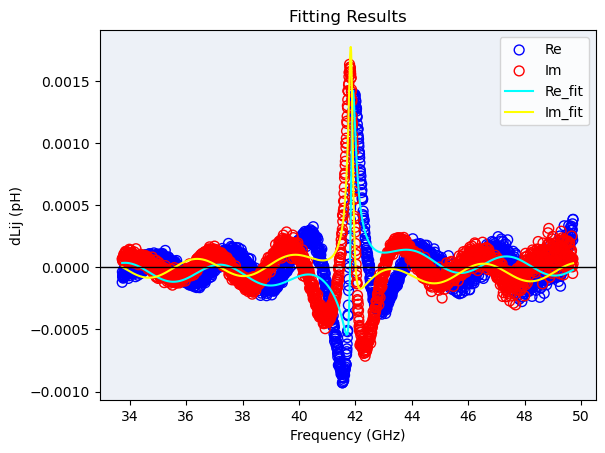


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.685e-04      3.762e-06                  No
Ai                     9.809e-05      3.763e-06                  No
fo                       41.8582         0.0026                  No
df                        0.0978         0.0026                  No
re0                   -1.522e-05      3.603e-06        pH        No
im0                   -2.290e-05      3.609e-06        pH        No
B                      7.373e-05      3.679e-06                  No
tau                       0.2956         0.0017                  No
phi                    1.653e-53         0.4370       rad        No
----------------------------------------------------------------------
Index= 24, Guide freq.=41.20452889959126


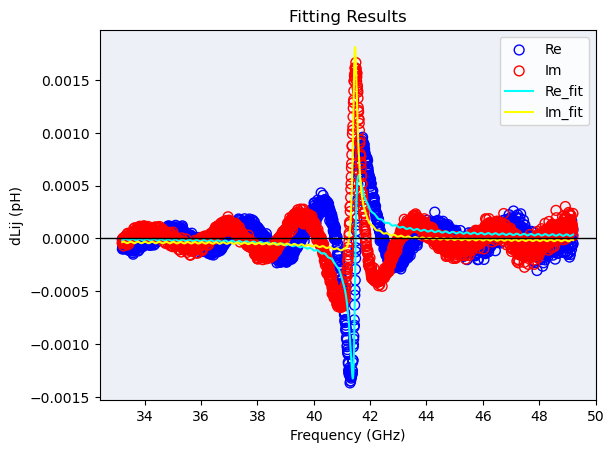


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.643e-04      3.602e-06                  No
Ai                    -7.032e-05      3.602e-06                  No
fo                       41.4470         0.0026                  No
df                        0.0927         0.0026                  No
re0                    9.409e-06      3.674e-06        pH        No
im0                   -2.946e-05      3.674e-06        pH        No
B                      6.788e-06      3.626e-06                  No
tau                       3.9615         0.0183                  No
phi                    9.384e-21         4.7701       rad        No
----------------------------------------------------------------------
Index= 25, Guide freq.=40.672808863480846


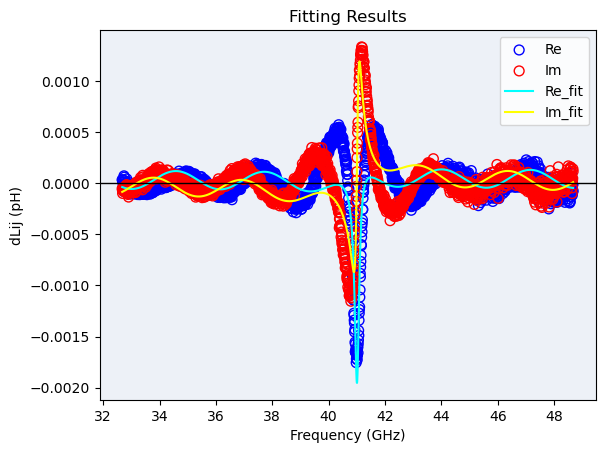


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.703e-05      3.656e-06                  No
Ai                    -2.015e-04      3.655e-06                  No
fo                       41.0116         0.0024                  No
df                        0.0979         0.0024                  No
re0                    3.580e-05      3.514e-06        pH        No
im0                   -7.124e-06      3.502e-06        pH        No
B                      8.827e-05      3.570e-06                  No
tau                       0.3181         0.0013                  No
phi                       6.2832         0.3456       rad        No
----------------------------------------------------------------------
Index= 26, Guide freq.=40.191903246454316


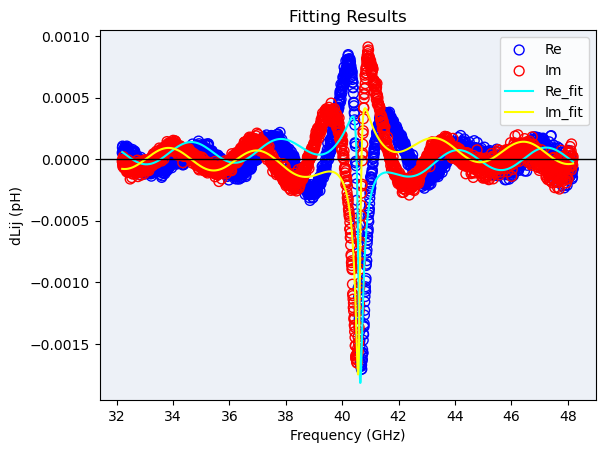


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.410e-04      3.686e-06                  No
Ai                    -1.573e-04      3.685e-06                  No
fo                       40.6047         0.0023                  No
df                        0.0960         0.0023                  No
re0                    2.779e-05      3.565e-06        pH        No
im0                    2.707e-05      3.582e-06        pH        No
B                      8.806e-05      3.636e-06                  No
tau                       0.3176         0.0014                  No
phi                       6.2832         0.3490       rad        No
----------------------------------------------------------------------
Index= 27, Guide freq.=39.658856873783954


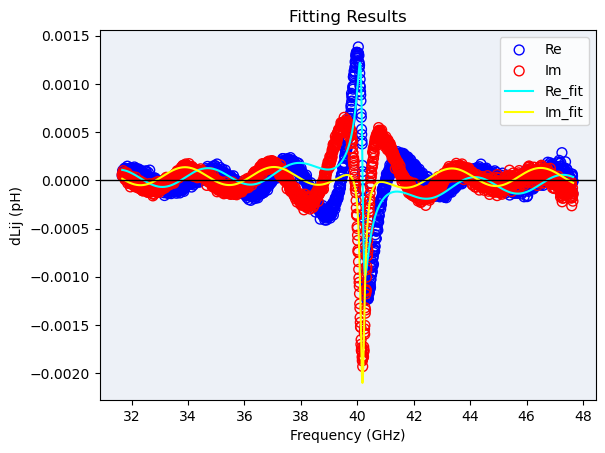


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.147e-04      3.778e-06                  No
Ai                     2.387e-05      3.779e-06                  No
fo                       40.1774         0.0023                  No
df                        0.0964         0.0023                  No
re0                   -5.716e-06      3.662e-06        pH        No
im0                    4.003e-05      3.653e-06        pH        No
B                      9.311e-05      3.720e-06                  No
tau                       0.3172         0.0013                  No
phi                       6.2832         0.3336       rad        No
----------------------------------------------------------------------
Index= 28, Guide freq.=39.17739767702677


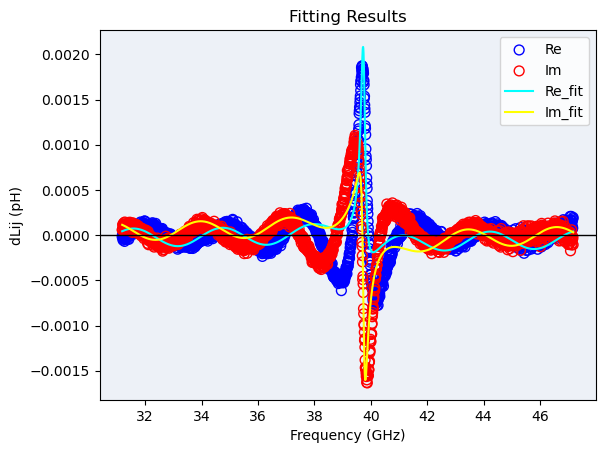


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.003e-04      3.935e-06                  No
Ai                     2.022e-04      3.935e-06                  No
fo                       39.7458         0.0023                  No
df                        0.0968         0.0023                  No
re0                   -3.839e-05      3.804e-06        pH        No
im0                    2.002e-05      3.796e-06        pH        No
B                      9.921e-05      3.865e-06                  No
tau                       0.3166         0.0013                  No
phi                       6.2832         0.3214       rad        No
----------------------------------------------------------------------
Index= 29, Guide freq.=38.70634597157212


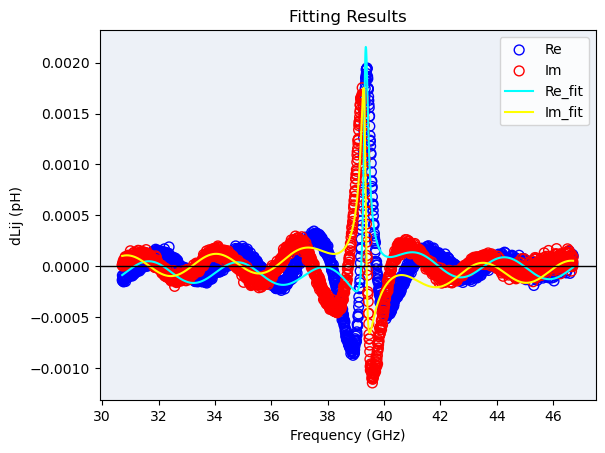


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.164e-04      4.107e-06                  No
Ai                     2.061e-04      4.106e-06                  No
fo                       39.3272         0.0023                  No
df                        0.0966         0.0023                  No
re0                   -3.993e-05      3.961e-06        pH        No
im0                   -2.124e-05      3.980e-06        pH        No
B                      1.047e-04      4.038e-06                  No
tau                       0.3171         0.0013                  No
phi                       6.0509         0.3142       rad        No
----------------------------------------------------------------------
Index= 30, Guide freq.=38.22661894684914


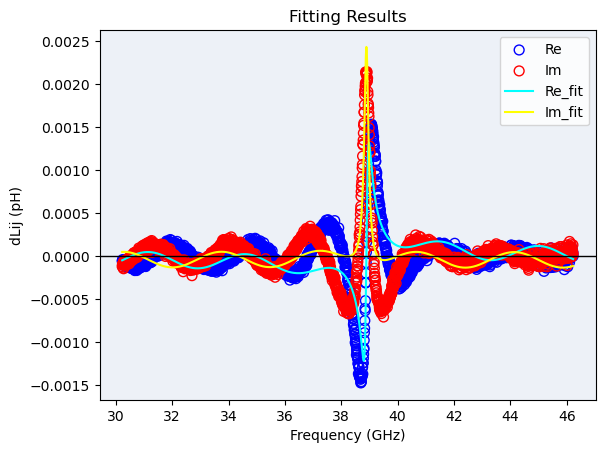


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.396e-04      4.233e-06                  No
Ai                     1.002e-05      4.234e-06                  No
fo                       38.8931         0.0022                  No
df                        0.0936         0.0022                  No
re0                   -1.113e-05      4.154e-06        pH        No
im0                   -4.185e-05      4.150e-06        pH        No
B                      9.033e-05      4.239e-06                  No
tau                       0.2889         0.0016                  No
phi                    7.053e-52         0.3756       rad        No
----------------------------------------------------------------------
Index= 31, Guide freq.=37.7761426638895


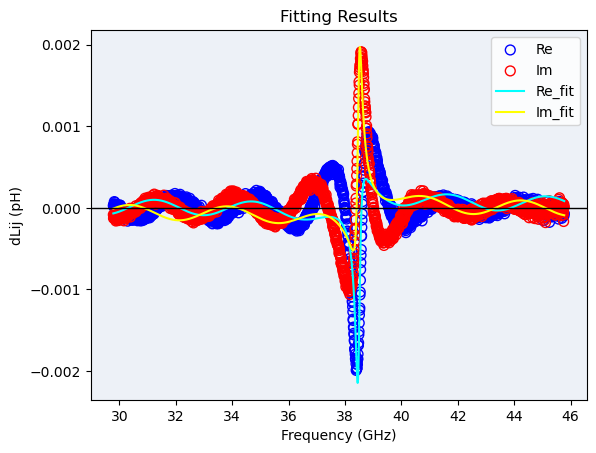


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.511e-04      4.274e-06                  No
Ai                    -1.884e-04      4.274e-06                  No
fo                       38.4800         0.0023                  No
df                        0.0953         0.0023                  No
re0                    2.876e-05      4.153e-06        pH        No
im0                   -3.251e-05      4.153e-06        pH        No
B                      9.106e-05      4.240e-06                  No
tau                       0.2881         0.0015                  No
phi                    7.522e-51         0.3683       rad        No
----------------------------------------------------------------------
Index= 32, Guide freq.=37.33476668035209


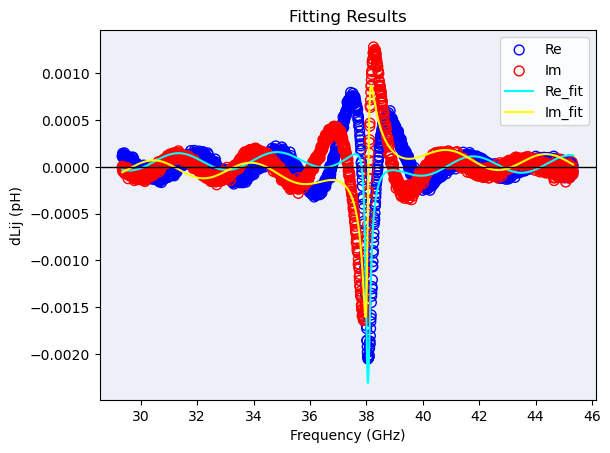


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.938e-05      4.298e-06                  No
Ai                    -2.290e-04      4.297e-06                  No
fo                       38.0380         0.0023                  No
df                        0.0967         0.0023                  No
re0                    4.361e-05      4.143e-06        pH        No
im0                    8.725e-06      4.146e-06        pH        No
B                      9.173e-05      4.232e-06                  No
tau                       0.2873         0.0015                  No
phi                    4.662e-53         0.3603       rad        No
----------------------------------------------------------------------
Index= 33, Guide freq.=36.90146774111733


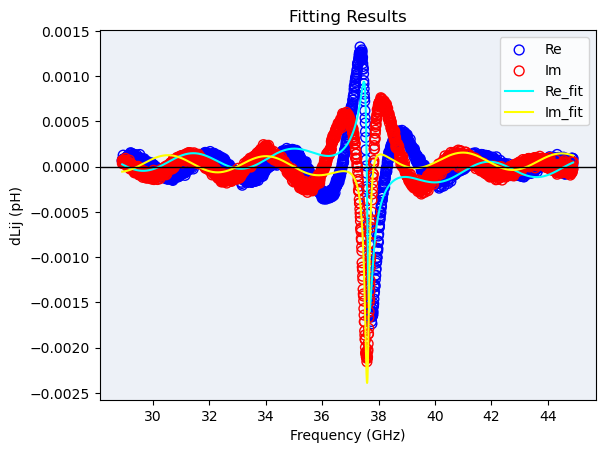


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.387e-04      4.328e-06                  No
Ai                    -6.942e-05      4.328e-06                  No
fo                       37.6031         0.0023                  No
df                        0.0965         0.0023                  No
re0                    1.693e-05      4.179e-06        pH        No
im0                    4.364e-05      4.177e-06        pH        No
B                      9.303e-05      4.267e-06                  No
tau                       0.2866         0.0015                  No
phi                    4.000e-53         0.3542       rad        No
----------------------------------------------------------------------
Index= 34, Guide freq.=36.474987789193854


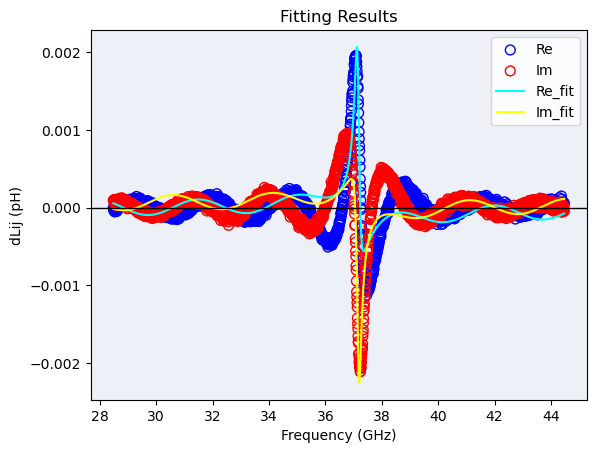


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.014e-04      4.435e-06                  No
Ai                     1.624e-04      4.435e-06                  No
fo                       37.1656         0.0023                  No
df                        0.0969         0.0023                  No
re0                   -2.697e-05      4.273e-06        pH        No
im0                    4.247e-05      4.272e-06        pH        No
B                      9.616e-05      4.363e-06                  No
tau                       0.2859         0.0015                  No
phi                    7.223e-46         0.3463       rad        No
----------------------------------------------------------------------
Index= 35, Guide freq.=36.018982597105804


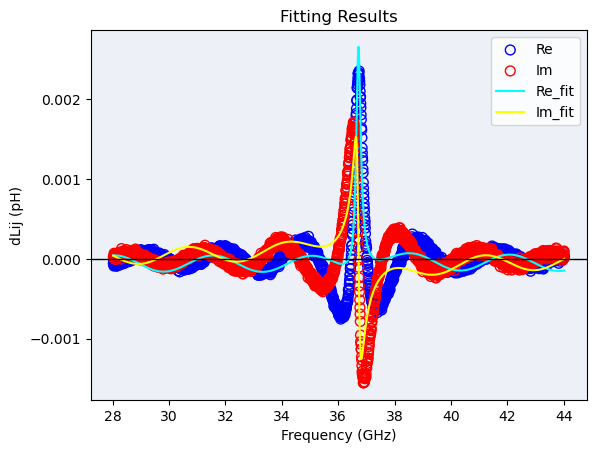


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.930e-05      4.592e-06                  No
Ai                     2.716e-04      4.590e-06                  No
fo                       36.7133         0.0022                  No
df                        0.0968         0.0022                  No
re0                   -5.430e-05      4.421e-06        pH        No
im0                    3.680e-06      4.423e-06        pH        No
B                      1.020e-04      4.516e-06                  No
tau                       0.2852         0.0015                  No
phi                    4.135e-50         0.3338       rad        No
----------------------------------------------------------------------
Index= 36, Guide freq.=35.60191062035317


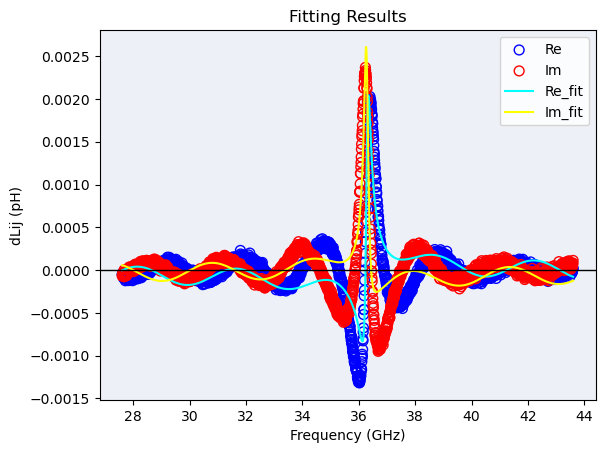


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.494e-04      4.731e-06                  No
Ai                     1.283e-04      4.731e-06                  No
fo                       36.2805         0.0022                  No
df                        0.0963         0.0022                  No
re0                   -3.204e-05      4.569e-06        pH        No
im0                   -4.198e-05      4.569e-06        pH        No
B                      1.029e-04      4.667e-06                  No
tau                       0.2842         0.0015                  No
phi                    8.735e-46         0.3377       rad        No
----------------------------------------------------------------------
Index= 37, Guide freq.=35.20411042515118


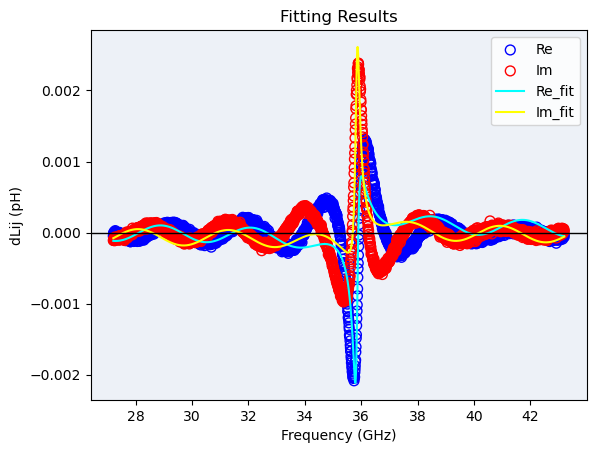


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.487e-04      4.832e-06                  No
Ai                    -1.416e-04      4.833e-06                  No
fo                       35.8440         0.0022                  No
df                        0.0969         0.0022                  No
re0                    2.400e-05      4.677e-06        pH        No
im0                   -4.659e-05      4.654e-06        pH        No
B                      1.129e-04      4.745e-06                  No
tau                       0.3115         0.0014                  No
phi                       6.2832         0.3124       rad        No
----------------------------------------------------------------------
Index= 38, Guide freq.=34.772075166480946


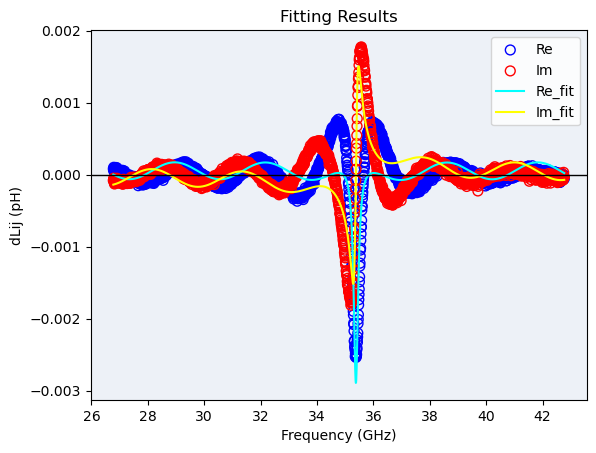


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.416e-06      4.991e-06                  No
Ai                    -2.952e-04      4.990e-06                  No
fo                       35.3786         0.0022                  No
df                        0.0962         0.0022                  No
re0                    5.406e-05      4.824e-06        pH        No
im0                    4.094e-07      4.844e-06        pH        No
B                      1.174e-04      4.917e-06                  No
tau                       0.3108         0.0014                  No
phi                       6.2832         0.3076       rad        No
----------------------------------------------------------------------
Index= 39, Guide freq.=34.33861668221955


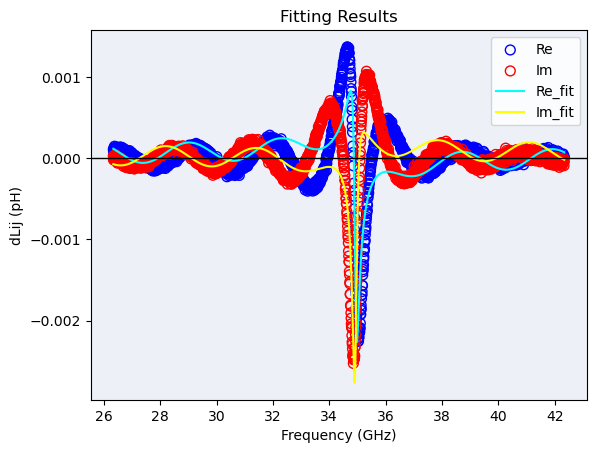


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.623e-04      5.219e-06                  No
Ai                    -1.537e-04      5.219e-06                  No
fo                       34.9233         0.0023                  No
df                        0.0968         0.0023                  No
re0                    2.789e-05      5.032e-06        pH        No
im0                    5.070e-05      5.043e-06        pH        No
B                      1.210e-04      5.124e-06                  No
tau                       0.3102         0.0014                  No
phi                       6.2832         0.3070       rad        No
----------------------------------------------------------------------
Index= 40, Guide freq.=33.937091143896396


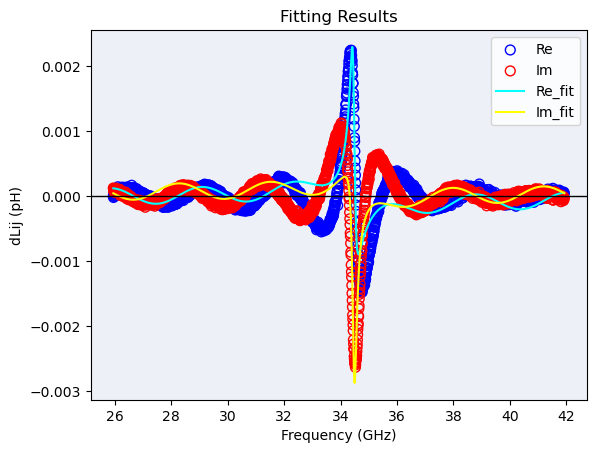


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.748e-04      5.425e-06                  No
Ai                     1.518e-04      5.425e-06                  No
fo                       34.4730         0.0023                  No
df                        0.0970         0.0023                  No
re0                   -3.006e-05      5.246e-06        pH        No
im0                    5.279e-05      5.216e-06        pH        No
B                      1.234e-04      5.323e-06                  No
tau                       0.3095         0.0014                  No
phi                       6.2832         0.3092       rad        No
----------------------------------------------------------------------
Index= 41, Guide freq.=33.47846700680013


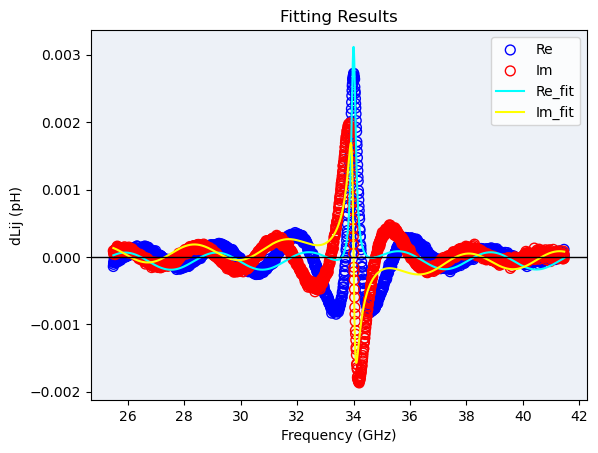


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.130e-05      5.541e-06                  No
Ai                     3.195e-04      5.540e-06                  No
fo                       33.9997         0.0023                  No
df                        0.0966         0.0023                  No
re0                   -6.235e-05      5.348e-06        pH        No
im0                    8.858e-07      5.361e-06        pH        No
B                      1.274e-04      5.449e-06                  No
tau                       0.3088         0.0014                  No
phi                       6.2832         0.3026       rad        No
----------------------------------------------------------------------
Index= 42, Guide freq.=33.049436421001545


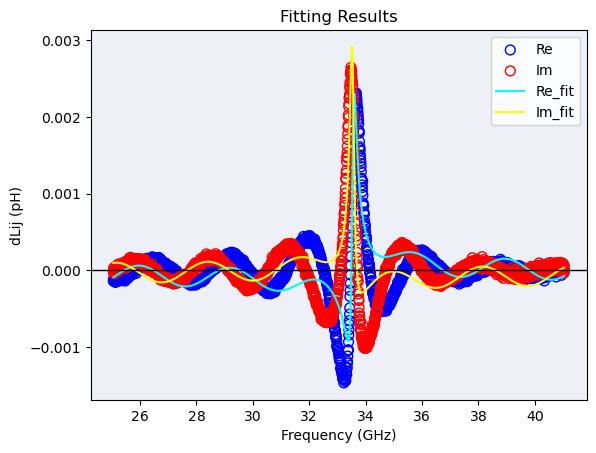


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.831e-04      5.640e-06                  No
Ai                     1.525e-04      5.640e-06                  No
fo                       33.5423         0.0023                  No
df                        0.0983         0.0023                  No
re0                   -3.203e-05      5.389e-06        pH        No
im0                   -4.924e-05      5.411e-06        pH        No
B                      1.306e-04      5.495e-06                  No
tau                       0.3081         0.0014                  No
phi                       6.2832         0.2936       rad        No
----------------------------------------------------------------------
Index= 43, Guide freq.=32.5956994740518


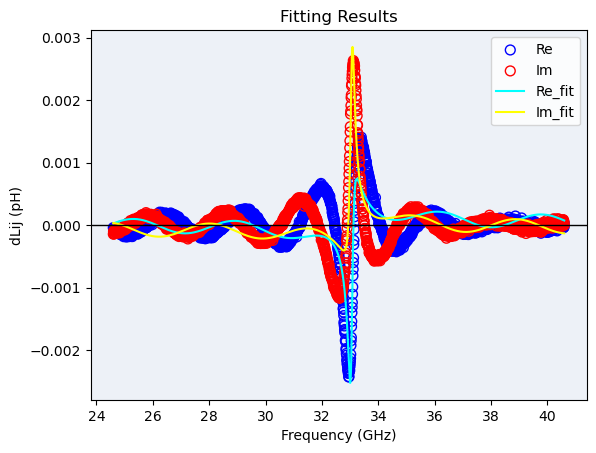


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.611e-04      5.891e-06                  No
Ai                    -1.904e-04      5.892e-06                  No
fo                       33.0519         0.0024                  No
df                        0.0978         0.0024                  No
re0                    2.395e-05      5.646e-06        pH        No
im0                   -4.687e-05      5.644e-06        pH        No
B                      1.100e-04      5.768e-06                  No
tau                       0.2765         0.0017                  No
phi                    4.072e-49         0.3584       rad        No
----------------------------------------------------------------------
Index= 44, Guide freq.=32.152877554573564


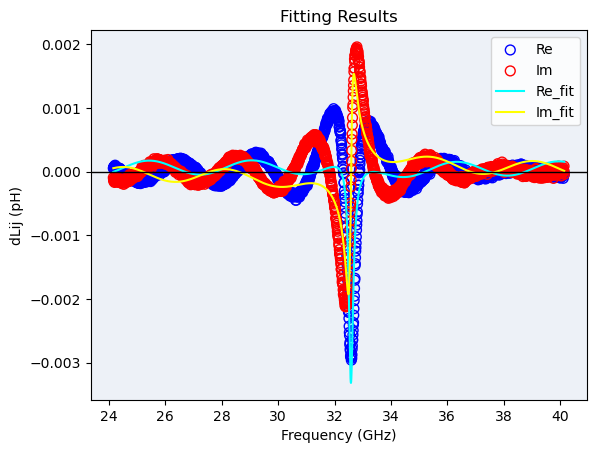


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.226e-05      6.082e-06                  No
Ai                    -3.360e-04      6.081e-06                  No
fo                       32.5768         0.0024                  No
df                        0.0969         0.0024                  No
re0                    5.512e-05      5.855e-06        pH        No
im0                    2.200e-06      5.856e-06        pH        No
B                      1.110e-04      5.982e-06                  No
tau                       0.2753         0.0018                  No
phi                    4.614e-50         0.3637       rad        No
----------------------------------------------------------------------
Index= 45, Guide freq.=31.702591227431384


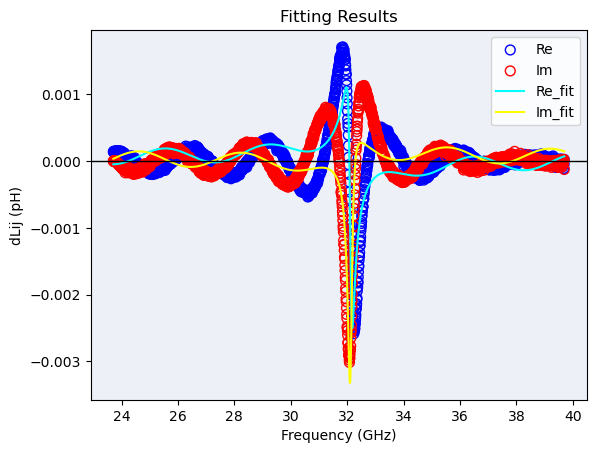


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.186e-04      6.250e-06                  No
Ai                    -1.451e-04      6.250e-06                  No
fo                       32.1203         0.0023                  No
df                        0.0960         0.0023                  No
re0                    2.777e-05      6.047e-06        pH        No
im0                    5.198e-05      6.050e-06        pH        No
B                      1.136e-04      6.179e-06                  No
tau                       0.2742         0.0018                  No
phi                    2.321e-49         0.3624       rad        No
----------------------------------------------------------------------
Index= 46, Guide freq.=31.225514519020603


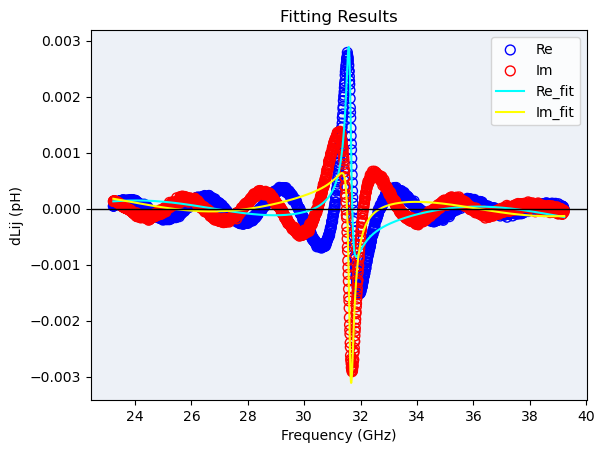


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.087e-04      7.032e-06                  No
Ai                     2.539e-04      7.043e-06                  No
fo                       31.6274         0.0025                  No
df                        0.1060         0.0025                  No
re0                   -7.730e-05      6.341e-06        pH        No
im0                    8.166e-05      6.343e-06        pH        No
B                      1.823e-04      6.718e-06                  No
tau                       0.0836         0.0011                  No
phi                       6.2832         0.2222       rad        No
----------------------------------------------------------------------
Index= 47, Guide freq.=30.760010405234876


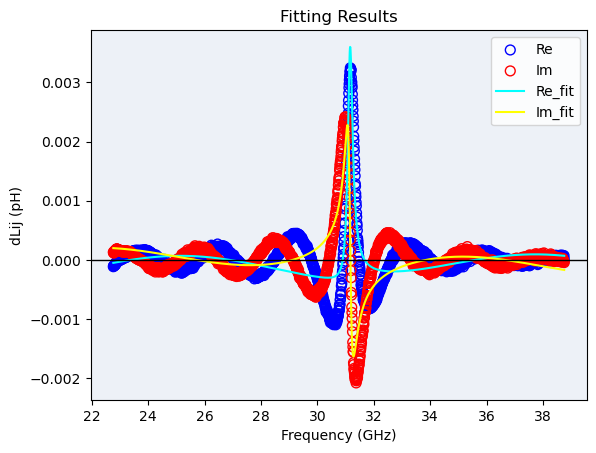


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.949e-05      7.189e-06                  No
Ai                     4.064e-04      7.184e-06                  No
fo                       31.1533         0.0024                  No
df                        0.1053         0.0024                  No
re0                   -1.089e-04      6.558e-06        pH        No
im0                   -2.697e-05      6.451e-06        pH        No
B                      1.897e-04      6.865e-06                  No
tau                       0.0794         0.0011                  No
phi                       6.2832         0.2187       rad        No
----------------------------------------------------------------------
Index= 48, Guide freq.=30.287596277783553


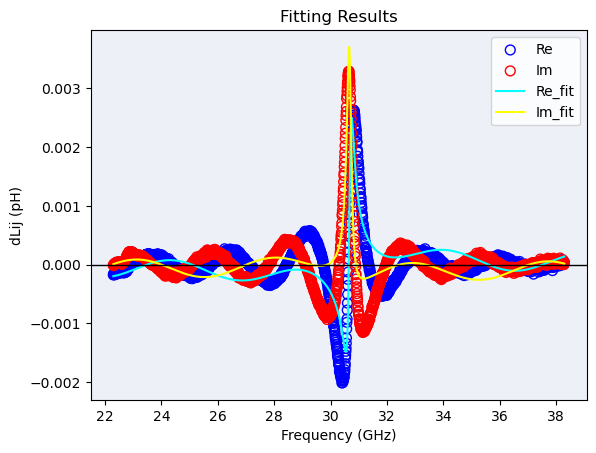


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.836e-04      7.056e-06                  No
Ai                     1.136e-04      7.056e-06                  No
fo                       30.6697         0.0024                  No
df                        0.0995         0.0024                  No
re0                   -1.806e-05      6.621e-06        pH        No
im0                   -8.254e-05      6.644e-06        pH        No
B                      1.536e-04      6.843e-06                  No
tau                       0.2055         0.0014                  No
phi                       6.2832         0.2788       rad        No
----------------------------------------------------------------------
Index= 49, Guide freq.=29.788858525112648


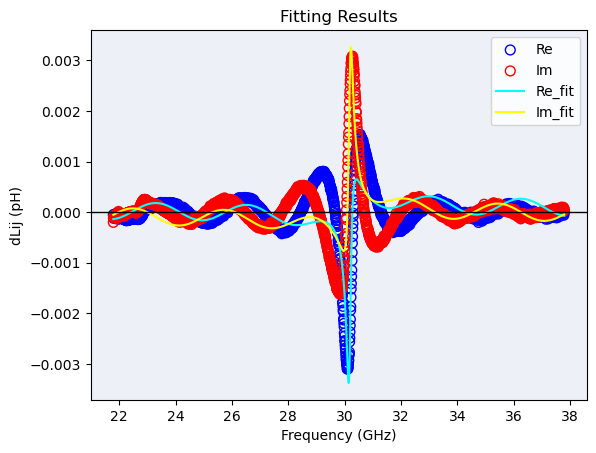


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.742e-04      7.005e-06                  No
Ai                    -2.979e-04      7.005e-06                  No
fo                       30.1777         0.0023                  No
df                        0.0986         0.0023                  No
re0                    5.539e-05      6.714e-06        pH        No
im0                   -5.276e-05      6.674e-06        pH        No
B                      1.645e-04      6.814e-06                  No
tau                       0.3088         0.0014                  No
phi                       5.0510         0.2612       rad        No
----------------------------------------------------------------------
Index= 50, Guide freq.=29.304545369589945


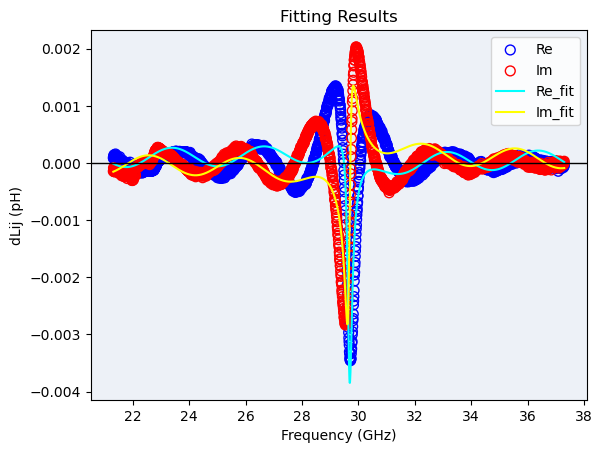


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.606e-04      7.313e-06                  No
Ai                    -3.890e-04      7.313e-06                  No
fo                       29.6769         0.0023                  No
df                        0.0992         0.0023                  No
re0                    7.558e-05      6.955e-06        pH        No
im0                    2.313e-05      6.979e-06        pH        No
B                      1.669e-04      7.092e-06                  No
tau                       0.3082         0.0014                  No
phi                       4.9796         0.2637       rad        No
----------------------------------------------------------------------
Index= 51, Guide freq.=28.79530673069929


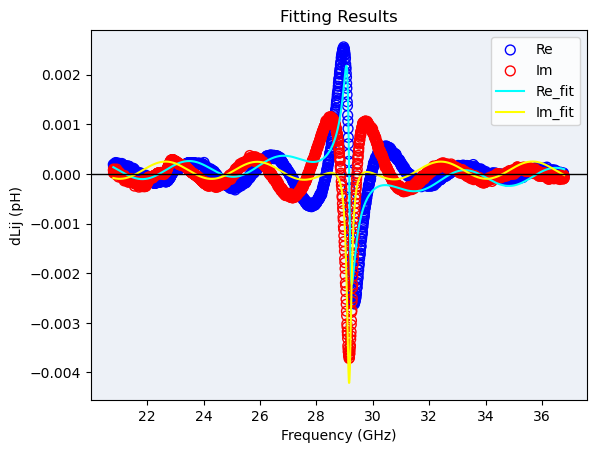


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.385e-04      7.575e-06                  No
Ai                    -5.914e-06      7.575e-06                  No
fo                       29.1638         0.0023                  No
df                        0.0982         0.0023                  No
re0                    7.922e-06      7.249e-06        pH        No
im0                    7.546e-05      7.258e-06        pH        No
B                      1.738e-04      7.385e-06                  No
tau                       0.3075         0.0014                  No
phi                       4.9146         0.2593       rad        No
----------------------------------------------------------------------
Index= 52, Guide freq.=28.302869593164537


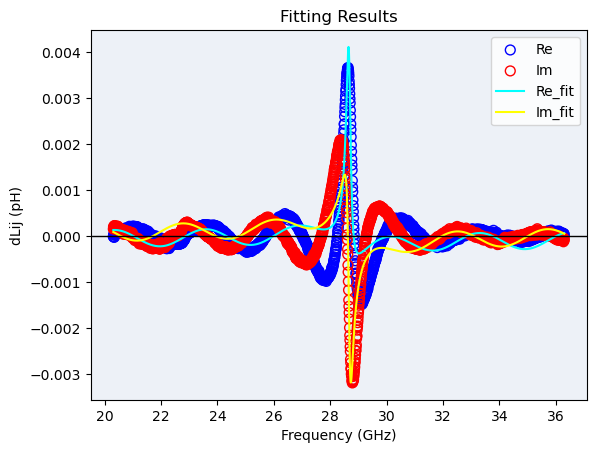


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.997e-04      7.831e-06                  No
Ai                     4.037e-04      7.831e-06                  No
fo                       28.6725         0.0023                  No
df                        0.0981         0.0023                  No
re0                   -6.795e-05      7.522e-06        pH        No
im0                    3.283e-05      7.482e-06        pH        No
B                      1.807e-04      7.637e-06                  No
tau                       0.3090         0.0014                  No
phi                       4.4813         0.2535       rad        No
----------------------------------------------------------------------
Index= 53, Guide freq.=27.807856024082735


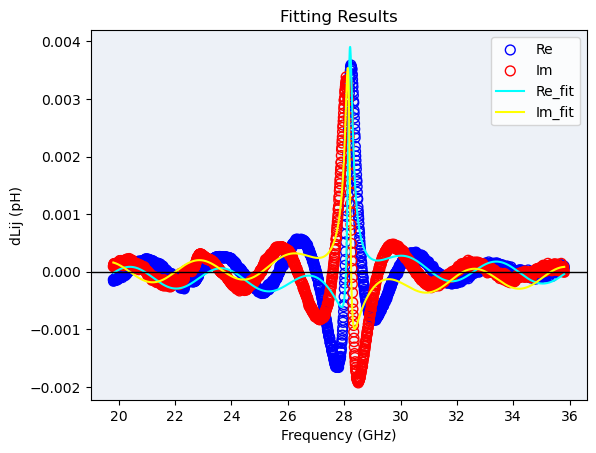


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.834e-04      8.065e-06                  No
Ai                     3.631e-04      8.065e-06                  No
fo                       28.1766         0.0024                  No
df                        0.1000         0.0024                  No
re0                   -6.359e-05      7.630e-06        pH        No
im0                   -5.265e-05      7.672e-06        pH        No
B                      1.842e-04      7.788e-06                  No
tau                       0.3076         0.0014                  No
phi                       4.5387         0.2492       rad        No
----------------------------------------------------------------------
Index= 54, Guide freq.=27.29031079058818


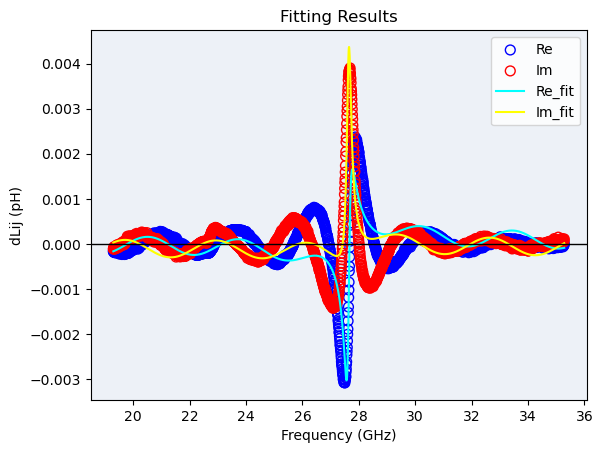


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.493e-04      8.264e-06                  No
Ai                    -1.510e-04      8.264e-06                  No
fo                       27.6374         0.0024                  No
df                        0.0996         0.0024                  No
re0                    3.012e-05      7.866e-06        pH        No
im0                   -8.259e-05      7.850e-06        pH        No
B                      1.915e-04      7.998e-06                  No
tau                       0.3094         0.0014                  No
phi                       4.0875         0.2418       rad        No
----------------------------------------------------------------------
Index= 55, Guide freq.=26.79221427189891


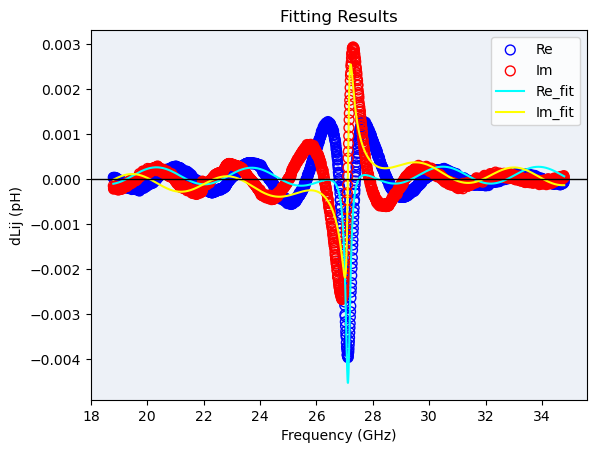


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.993e-05      8.710e-06                  No
Ai                    -4.827e-04      8.711e-06                  No
fo                       27.1195         0.0025                  No
df                        0.1009         0.0025                  No
re0                    7.940e-05      8.222e-06        pH        No
im0                   -1.341e-05      8.209e-06        pH        No
B                      1.873e-04      8.380e-06                  No
tau                       0.2952         0.0015                  No
phi                    1.498e-46         0.2535       rad        No
----------------------------------------------------------------------
Index= 56, Guide freq.=26.293154942416713


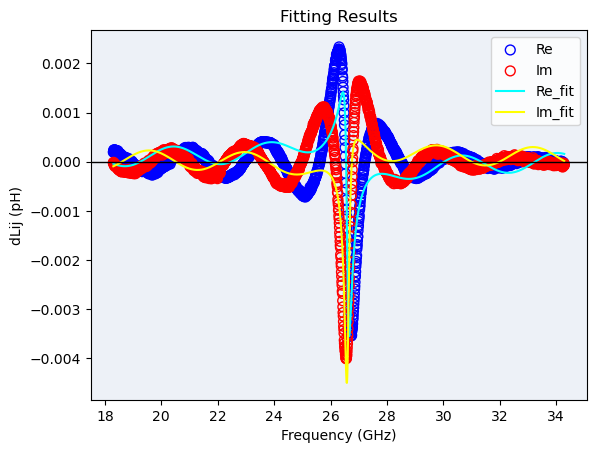


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.457e-04      8.968e-06                  No
Ai                    -2.341e-04      8.968e-06                  No
fo                       26.6020         0.0024                  No
df                        0.0999         0.0024                  No
re0                    4.462e-05      8.494e-06        pH        No
im0                    7.029e-05      8.517e-06        pH        No
B                      1.931e-04      8.679e-06                  No
tau                       0.2938         0.0015                  No
phi                    1.032e-43         0.2502       rad        No
----------------------------------------------------------------------
Index= 57, Guide freq.=25.772157280755536


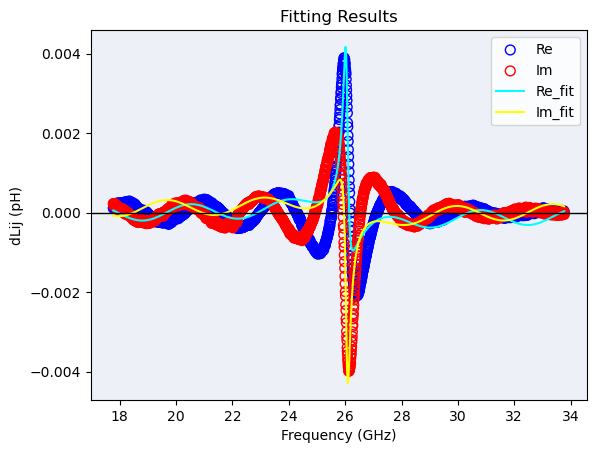


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.794e-04      9.384e-06                  No
Ai                     3.563e-04      9.384e-06                  No
fo                       26.0568         0.0025                  No
df                        0.1000         0.0025                  No
re0                   -5.408e-05      8.899e-06        pH        No
im0                    6.587e-05      8.880e-06        pH        No
B                      1.982e-04      9.073e-06                  No
tau                       0.2924         0.0015                  No
phi                    7.123e-47         0.2497       rad        No
----------------------------------------------------------------------
Index= 58, Guide freq.=25.29129525127635


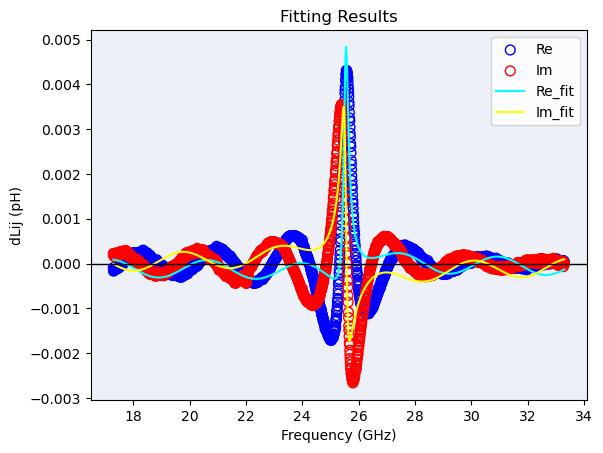


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.981e-04      9.732e-06                  No
Ai                     4.971e-04      9.733e-06                  No
fo                       25.5310         0.0025                  No
df                        0.1010         0.0025                  No
re0                   -8.493e-05      9.173e-06        pH        No
im0                   -2.724e-05      9.176e-06        pH        No
B                      2.004e-04      9.365e-06                  No
tau                       0.2910         0.0015                  No
phi                    3.119e-50         0.2502       rad        No
----------------------------------------------------------------------
Index= 59, Guide freq.=24.765880088831356


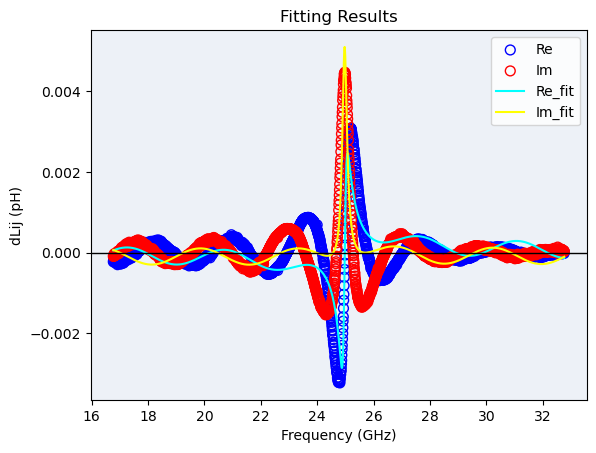


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.498e-04      1.016e-05                  No
Ai                    -4.437e-05      1.016e-05                  No
fo                       24.9691         0.0026                  No
df                        0.1021         0.0026                  No
re0                   -1.532e-06      9.520e-06        pH        No
im0                   -8.953e-05      9.528e-06        pH        No
B                      2.019e-04      9.724e-06                  No
tau                       0.2895         0.0016                  No
phi                    1.575e-47         0.2526       rad        No
----------------------------------------------------------------------
Index= 60, Guide freq.=24.235966280863433


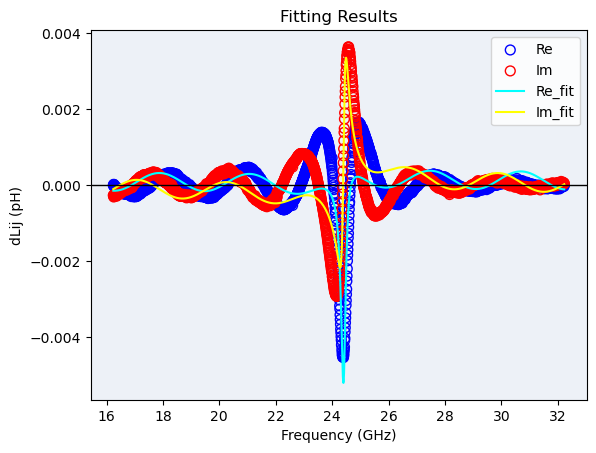


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.350e-04      1.050e-05                  No
Ai                    -5.626e-04      1.050e-05                  No
fo                       24.4113         0.0025                  No
df                        0.1030         0.0025                  No
re0                    1.004e-04      9.841e-06        pH        No
im0                   -2.562e-05      9.782e-06        pH        No
B                      2.353e-04      9.985e-06                  No
tau                       0.3121         0.0014                  No
phi                       2.6440         0.2189       rad        No
----------------------------------------------------------------------
Index= 61, Guide freq.=23.72094821476794


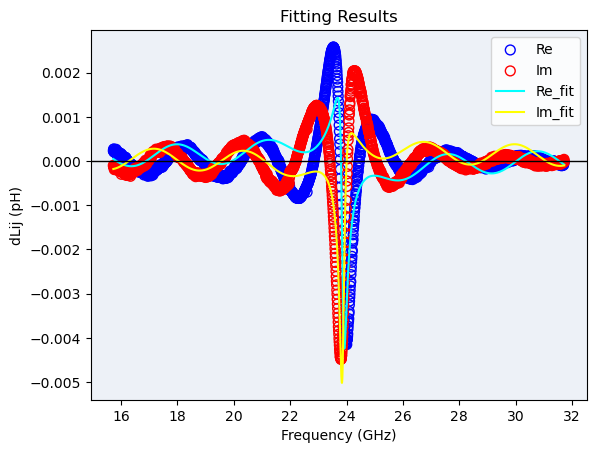


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.029e-04      1.095e-05                  No
Ai                    -3.236e-04      1.095e-05                  No
fo                       23.8641         0.0026                  No
df                        0.1034         0.0026                  No
re0                    5.699e-05      1.018e-05        pH        No
im0                    9.030e-05      1.023e-05        pH        No
B                      2.399e-04      1.039e-05                  No
tau                       0.3127         0.0014                  No
phi                       2.3944         0.2187       rad        No
----------------------------------------------------------------------
Index= 62, Guide freq.=23.175270107066346


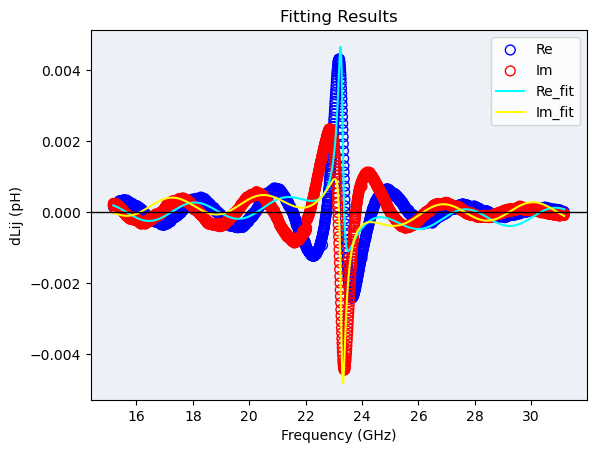


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.551e-04      1.149e-05                  No
Ai                     4.131e-04      1.149e-05                  No
fo                       23.2824         0.0027                  No
df                        0.1048         0.0027                  No
re0                   -7.631e-05      1.065e-05        pH        No
im0                    8.236e-05      1.063e-05        pH        No
B                      2.494e-04      1.083e-05                  No
tau                       0.3126         0.0014                  No
phi                       2.2291         0.2145       rad        No
----------------------------------------------------------------------
Index= 63, Guide freq.=22.639717094086535


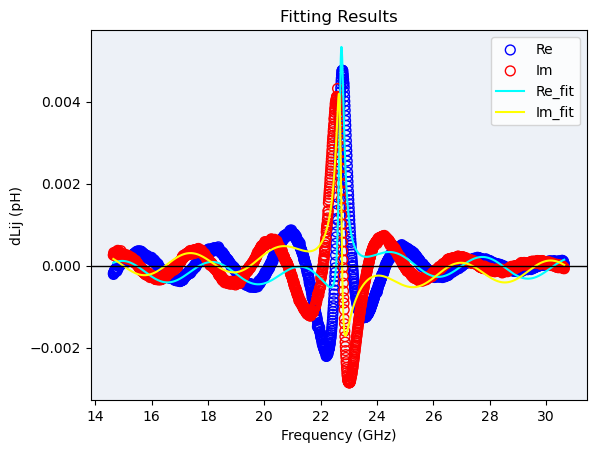


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.914e-04      1.196e-05                  No
Ai                     5.609e-04      1.196e-05                  No
fo                       22.7097         0.0027                  No
df                        0.1051         0.0027                  No
re0                   -1.034e-04      1.107e-05        pH        No
im0                   -5.484e-05      1.105e-05        pH        No
B                      2.576e-04      1.125e-05                  No
tau                       0.3128         0.0015                  No
phi                       2.0142         0.2109       rad        No
----------------------------------------------------------------------
Index= 64, Guide freq.=22.089644803779485


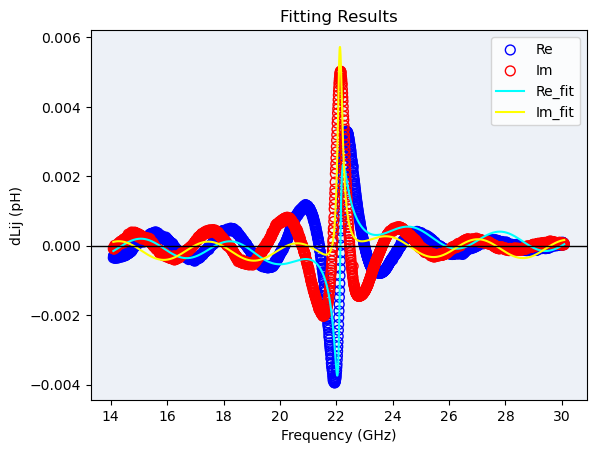


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.409e-04      1.256e-05                  No
Ai                    -1.660e-04      1.256e-05                  No
fo                       22.1170         0.0027                  No
df                        0.1067         0.0027                  No
re0                    2.841e-05      1.149e-05        pH        No
im0                   -1.153e-04      1.155e-05        pH        No
B                      2.667e-04      1.172e-05                  No
tau                       0.3140         0.0015                  No
phi                       1.6589         0.2072       rad        No
----------------------------------------------------------------------
Index= 65, Guide freq.=21.49786035058959


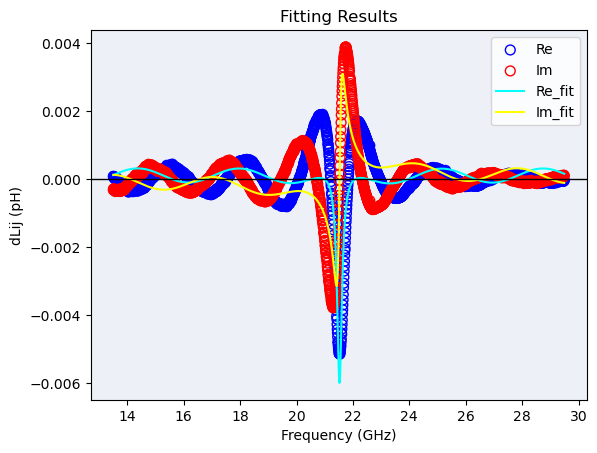


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.202e-06      1.345e-05                  No
Ai                    -6.760e-04      1.345e-05                  No
fo                       21.5235         0.0029                  No
df                        0.1071         0.0029                  No
re0                    1.050e-04      1.230e-05        pH        No
im0                    1.301e-06      1.230e-05        pH        No
B                      2.077e-04      1.256e-05                  No
tau                       0.2783         0.0020                  No
phi                    5.044e-54         0.2766       rad        No
----------------------------------------------------------------------
Index= 66, Guide freq.=20.90857300256306


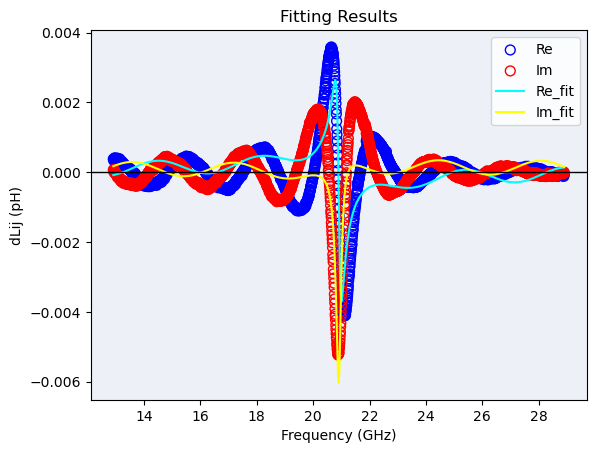


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.801e-04      1.411e-05                  No
Ai                    -1.260e-04      1.411e-05                  No
fo                       20.9124         0.0030                  No
df                        0.1081         0.0030                  No
re0                    2.001e-05      1.284e-05        pH        No
im0                    1.094e-04      1.285e-05        pH        No
B                      2.021e-04      1.311e-05                  No
tau                       0.2760         0.0021                  No
phi                    9.145e-46         0.2890       rad        No
----------------------------------------------------------------------
Index= 67, Guide freq.=20.269680319190353


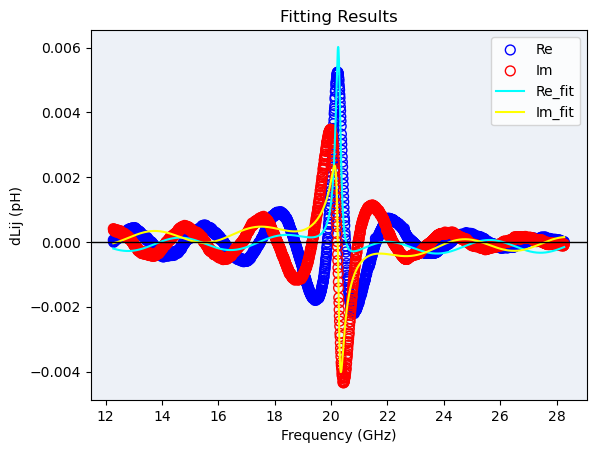


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.970e-04      1.482e-05                  No
Ai                     6.740e-04      1.482e-05                  No
fo                       20.2655         0.0031                  No
df                        0.1088         0.0031                  No
re0                   -1.064e-04      1.345e-05        pH        No
im0                    3.504e-05      1.344e-05        pH        No
B                      2.013e-04      1.372e-05                  No
tau                       0.2734         0.0023                  No
phi                    5.678e-45         0.2950       rad        No
----------------------------------------------------------------------
Index= 68, Guide freq.=19.62997816704504


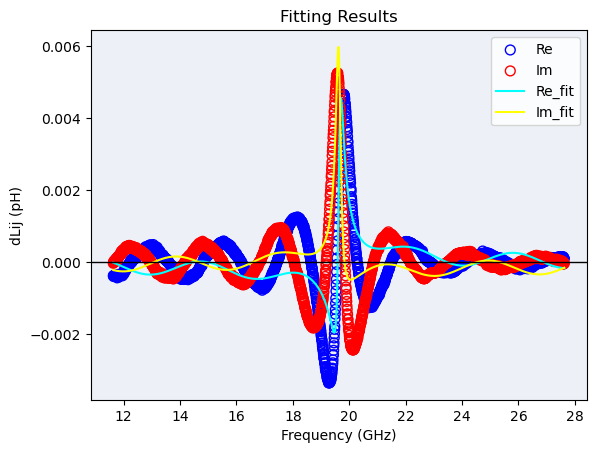


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.569e-04      1.571e-05                  No
Ai                     3.115e-04      1.571e-05                  No
fo                       19.6380         0.0032                  No
df                        0.1106         0.0032                  No
re0                   -5.412e-05      1.413e-05        pH        No
im0                   -1.039e-04      1.414e-05        pH        No
B                      2.001e-04      1.442e-05                  No
tau                       0.2710         0.0024                  No
phi                    9.131e-42         0.3026       rad        No
----------------------------------------------------------------------
Index= 69, Guide freq.=18.96289923935835


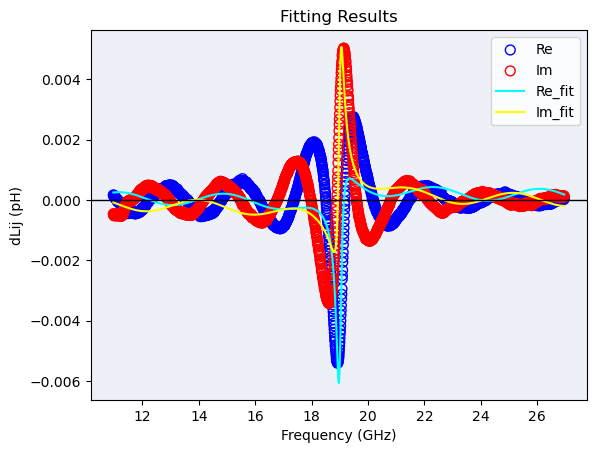


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.106e-04      1.678e-05                  No
Ai                    -6.481e-04      1.678e-05                  No
fo                       18.9954         0.0033                  No
df                        0.1114         0.0033                  No
re0                    1.073e-04      1.505e-05        pH        No
im0                   -7.533e-05      1.503e-05        pH        No
B                      2.065e-04      1.533e-05                  No
tau                       0.2682         0.0025                  No
phi                    5.904e-44         0.3020       rad        No
----------------------------------------------------------------------
Index= 70, Guide freq.=18.23823595494676


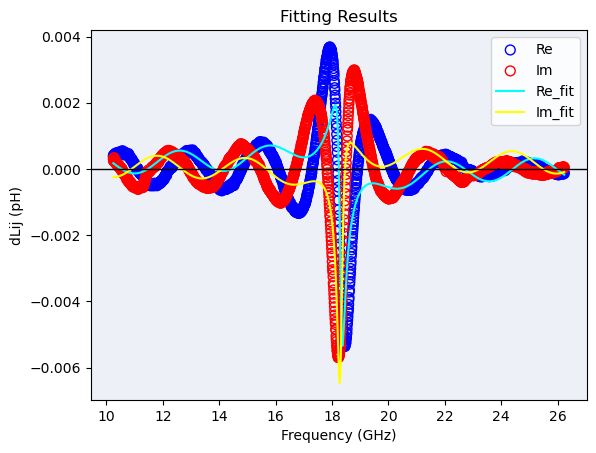


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.286e-04      1.778e-05                  No
Ai                    -4.344e-04      1.778e-05                  No
fo                       18.3031         0.0032                  No
df                        0.1141         0.0032                  No
re0                    9.678e-05      1.574e-05        pH        No
im0                    1.354e-04      1.581e-05        pH        No
B                      3.319e-04      1.604e-05                  No
tau                       0.3179         0.0016                  No
phi                    2.340e-43         0.1898       rad        No
----------------------------------------------------------------------
Index= 71, Guide freq.=17.51435113659126


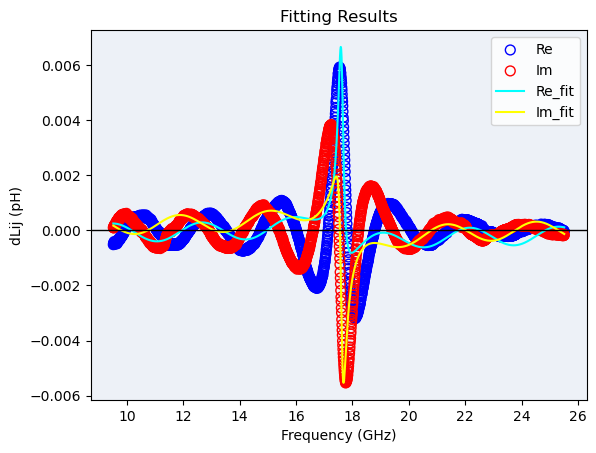


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.561e-04      1.901e-05                  No
Ai                     7.555e-04      1.901e-05                  No
fo                       17.6181         0.0034                  No
df                        0.1152         0.0034                  No
re0                   -1.381e-04      1.681e-05        pH        No
im0                    9.747e-05      1.673e-05        pH        No
B                      3.315e-04      1.705e-05                  No
tau                       0.3161         0.0017                  No
phi                    1.220e-61         0.1944       rad        No
----------------------------------------------------------------------
Index= 72, Guide freq.=16.764222736182983


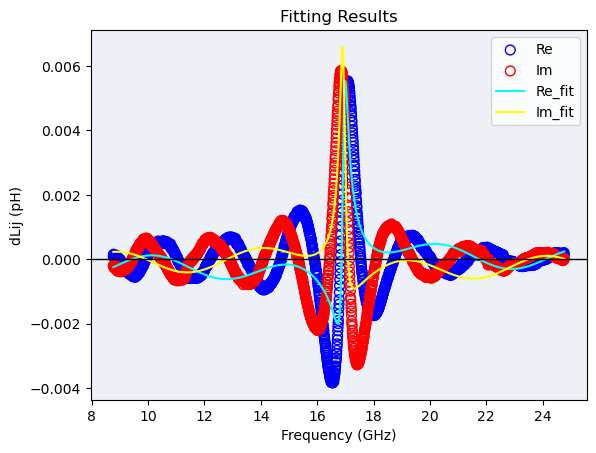


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.845e-04      2.094e-05                  No
Ai                     4.857e-04      2.094e-05                  No
fo                       16.9307         0.0037                  No
df                        0.1210         0.0037                  No
re0                   -9.845e-05      1.763e-05        pH        No
im0                   -1.631e-04      1.778e-05        pH        No
B                      3.354e-04      1.828e-05                  No
tau                       0.1969         0.0018                  No
phi                    1.112e-46         0.1942       rad        No
----------------------------------------------------------------------
Index= 73, Guide freq.=15.957235888393127


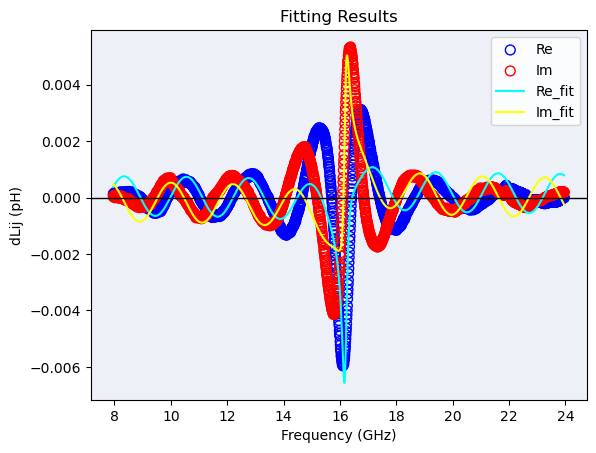


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.417e-04      1.728e-05                  No
Ai                    -5.997e-04      1.728e-05                  No
fo                       16.1862         0.0037                  No
df                        0.1078         0.0037                  No
re0                    1.006e-04      1.599e-05        pH        No
im0                   -7.313e-05      1.597e-05        pH        No
B                      6.979e-04      1.608e-05                  No
tau                       0.4523      7.709e-04                  No
phi                       1.4266         0.0806       rad        No
----------------------------------------------------------------------
Index= 74, Guide freq.=15.193933411612997


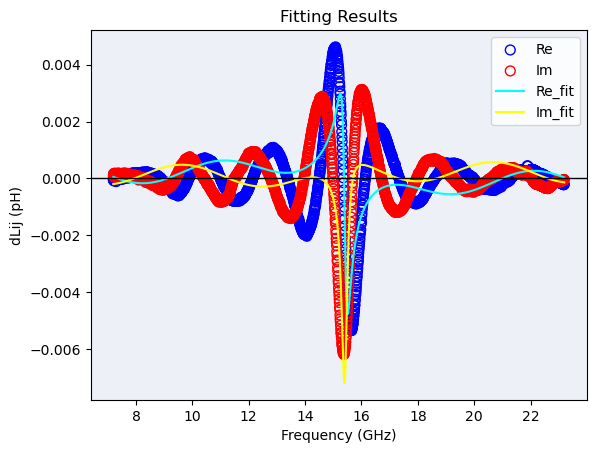


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -9.575e-04      2.407e-05                  No
Ai                    -2.620e-04      2.407e-05                  No
fo                       15.4127         0.0041                  No
df                        0.1264         0.0041                  No
re0                    5.561e-05      1.969e-05        pH        No
im0                    1.727e-04      2.005e-05        pH        No
B                      3.578e-04      2.052e-05                  No
tau                       0.1812         0.0019                  No
phi                    9.245e-68         0.1884       rad        No
----------------------------------------------------------------------
Index= 75, Guide freq.=14.342886382703487


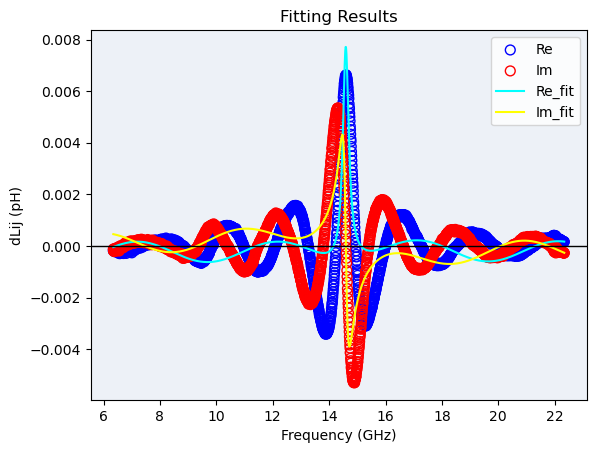


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.604e-05      2.614e-05                  No
Ai                        0.0011      2.614e-05                  No
fo                       14.5863         0.0042                  No
df                        0.1275         0.0042                  No
re0                   -2.226e-04      2.157e-05        pH        No
im0                   -2.091e-05      2.146e-05        pH        No
B                      3.950e-04      2.223e-05                  No
tau                       0.2011         0.0018                  No
phi                       3.4648         0.1730       rad        No
----------------------------------------------------------------------
Index= 76, Guide freq.=13.467320885781366


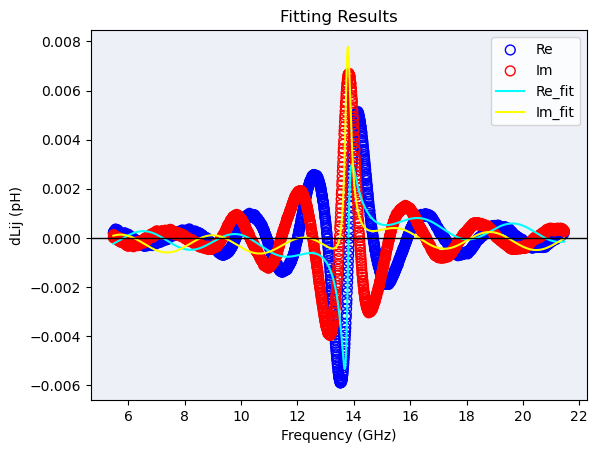


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0010      2.718e-05                  No
Ai                    -3.250e-04      2.718e-05                  No
fo                       13.7724         0.0043                  No
df                        0.1257         0.0043                  No
re0                    5.618e-05      2.294e-05        pH        No
im0                   -1.889e-04      2.292e-05        pH        No
B                      3.587e-04      2.329e-05                  No
tau                       0.3054         0.0022                  No
phi                    6.752e-77         0.1933       rad        No
----------------------------------------------------------------------
Index= 77, Guide freq.=12.594053561884772


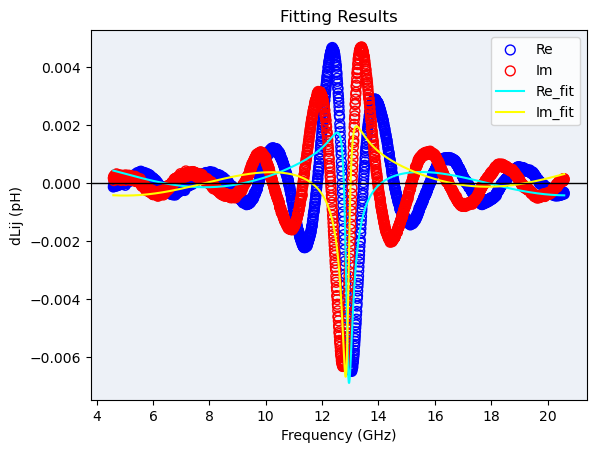


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.605e-04      3.434e-05                  No
Ai                    -9.286e-04      3.433e-05                  No
fo                       12.8992         0.0050                  No
df                        0.1450         0.0050                  No
re0                    2.447e-04      2.565e-05        pH        No
im0                    2.447e-04      2.572e-05        pH        No
B                      5.606e-04      2.762e-05                  No
tau                       0.0786         0.0015                  No
phi                       5.4385         0.1254       rad        No
----------------------------------------------------------------------
Index= 78, Guide freq.=11.624687665861373


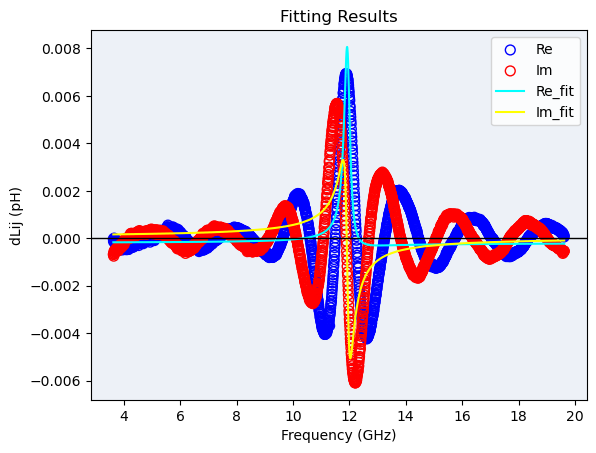


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.323e-04      3.092e-05                  No
Ai                        0.0010      3.092e-05                  No
fo                       11.9323         0.0051                  No
df                        0.1262         0.0051                  No
re0                   -1.996e-04      2.700e-05        pH        No
im0                    4.010e-05      2.700e-05        pH        No
B                      1.297e-06      2.633e-05                  No
tau                       7.2177         0.6992                  No
phi                       5.4178        54.9508       rad        No
----------------------------------------------------------------------
Index= 79, Guide freq.=10.584777848370631


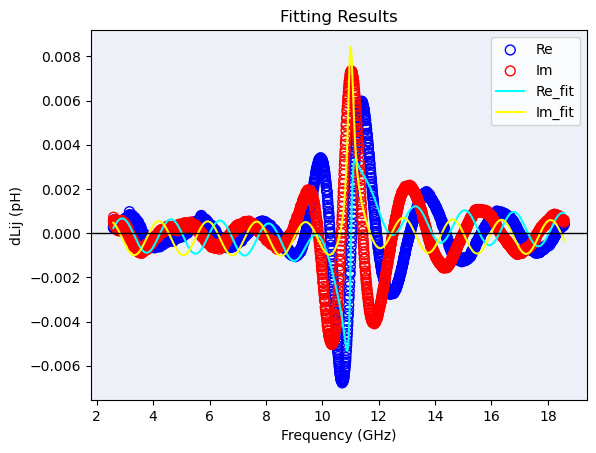


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0010      3.188e-05                  No
Ai                    -1.811e-04      3.188e-05                  No
fo                       10.9930         0.0054                  No
df                        0.1270         0.0054                  No
re0                    2.063e-05      2.742e-05        pH        No
im0                   -2.033e-04      2.741e-05        pH        No
B                      7.672e-04      2.729e-05                  No
tau                       0.5757         0.0012                  No
phi                       2.0889         0.0873       rad        No
----------------------------------------------------------------------
Index= 80, Guide freq.=9.39203169923131


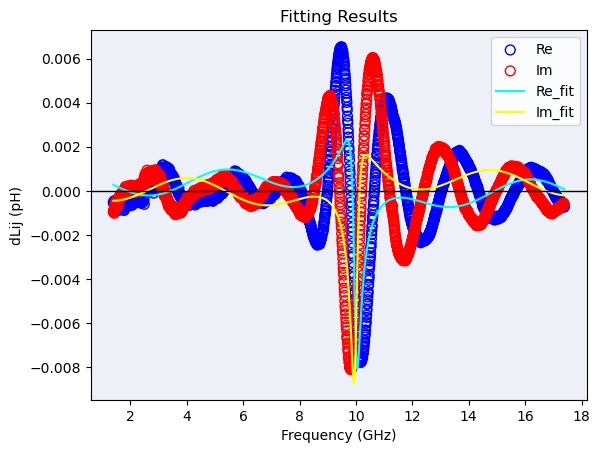


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                       -0.0012      4.474e-05                  No
Ai                    -9.702e-04      4.476e-05                  No
fo                        9.9809         0.0056                  No
df                        0.1456         0.0056                  No
re0                    1.704e-04      3.398e-05        pH        No
im0                    2.067e-04      3.456e-05        pH        No
B                      5.447e-04      3.536e-05                  No
tau                       0.1858         0.0021                  No
phi                       6.2832         0.1405       rad        No
----------------------------------------------------------------------


In [63]:
est_gamma = 28.8 #GHz/T
est_hx = 2171.0/1000 #T
est_hy = 42.8/1000 #T

for i in range(len(ansy1.calc_field("inP"))):
    H_index = i
    freq = res_func.kittel_general(ansy1.calc_field("inP")[H_index],est_gamma, est_hx, est_hy)
    print(f"Index= {i}, Guide freq.={freq}")
    ini_vals = [1, 1, freq, 0.028, 0, 0, 0.0001, 0.175, 0] #A, w, fres, fper, fref, re0, im0, "B","tau","phi"

    
    f_min, f_max = freq-8, freq+8 #GHz
    f_array = ansy1.freqs
    y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
    
    model = models.ComplexLorentzianRipple_freq()
    fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
        f_array, y_array_re , y_array_im, model)
    fitter.fix(fo=freq, df=0.02, re0=0, im0=0) # Parameters to be fixed, empty otherwise
    opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
    #print(opt_p0)
    #fitter.plot_fit_simplex_wpm()
    new_p0 = np.array(list(opt_p0.values()), dtype=float)
    fitter.update_p0(new_p0)
    
    params, cov = fitter.fit(simplex_b=False)
    fitter.plot_fit()
    fitter.summary()
    fit_dict = fitter.export_fit_dict()
    fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [65]:
#Realoading parameters

In [67]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

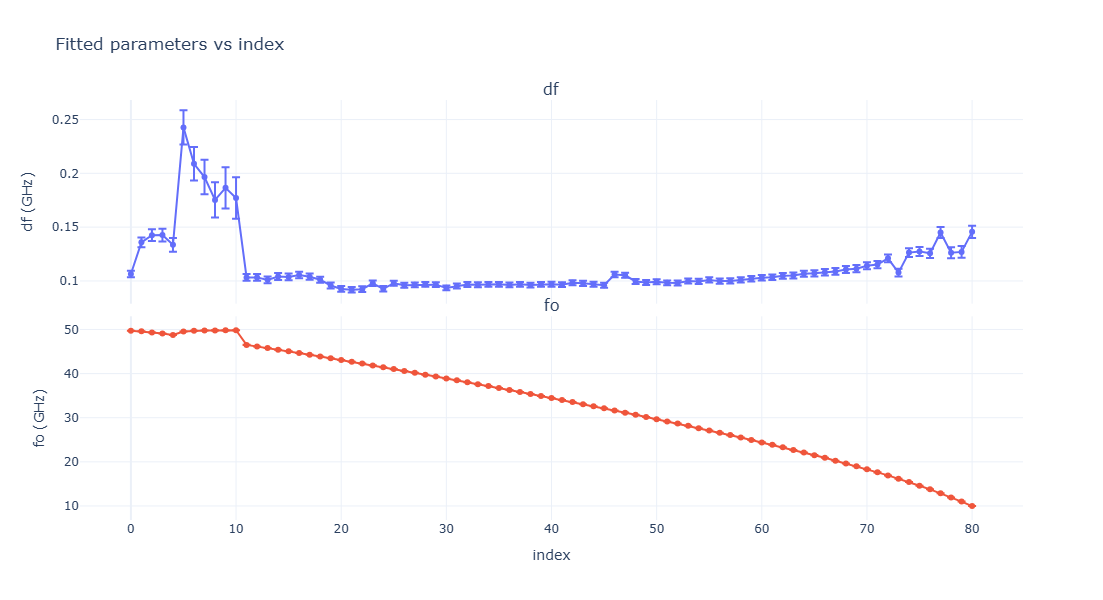

In [69]:
fits_storage.plot_fit_parameters_subplots(
    data_L_fits,
    x_axis="index",
    params=["df", "fo"],
    x_label= "index"#"μ₀H (T)"
)

In [28]:
cut_data_L_fits = fits_storage.slice_dict(data_L_fits, 15, 72)

In [29]:
#Plotting of fitted parameters